# COMPSCI 760 Group 9: synthesis of research questions Q1 to Q9

**Project:** Robustness and Accent Sensitivity in Direct vs. Cascaded Speech-to-Text Translation
**Author of this notebook:** Jidni Mayukh (Member 5)
**Runs on:** Google Colab (CPU is enough) or any local checkout of the team repository

## What this notebook does

I answer the nine research questions from the 1 October action plan in one place. Every answer follows the same four-part block: the question, the evidence (loaded from files that are already tracked in the repository), a written explanation, and a one-sentence concluding statement. The notebook ends with an all-inclusive summary, a self-contained HTML dashboard of the main figures, and a README for that dashboard.

No model is rerun here. Everything is computed on CPU from the tracked prediction CSVs, the tracked metric table, and the tracked statistical result CSVs. Where I add a new calculation (unk-free intervals, worst-clip audit, held-out sensitivity, fallback test) I say so, and I save the result to `runs/synthesis_results/`.

## How the evidence was built, and by whom

The evidence chain runs through the whole team, and I name the author of each input where it is used:

1. **Arizona Xing** prepared the frozen 4,200-clip, seven-accent evaluation set (`01_data_preprocessing.ipynb`, `02_audio_extraction.ipynb`) and later ran the extended `<unk>` analysis in `unk_analysis/`.
2. **Nathan Naylin** ran the frozen inference pipelines for Direct, Cascade-600M and Cascade-3.3B (`03_direct_pipeline.ipynb`, `04_cascaded_pipeline.ipynb`, three `runs/*_full_run_*` directories), ran the first `<unk>` diagnostics and sensitivity experiments (notebooks 05 to 07), committed the fixed evaluation notebook and its results, and maintains the README.
3. **I (Jidni)** built the base two-system evaluation: the Direct and Cascade merge on `id`, raw and normalised WER with jiwer, BLEU with the `zh` tokenizer after finding that the default tokenizer scores Chinese at 0.0, chrF and chrF++ through sacrebleu, and the written plan for paired bootstrap and Spearman analysis.
4. **Patricia Jennesha** extended that evaluation to three systems in `08_evaluation.ipynb`: she checked that both cascades have identical ASR transcripts (0 differences in 4,200), added per-clip chrF++ and gap columns, and produced the merged metric table and tables T1 to T5. Nathan then fixed the notebook and committed it with its saved outputs, `runs/08_evaluation.pdf` and `runs/evaluation_results/merged_3system_with_metrics.csv`.
5. **Zhitong Li** added the pseudonymous speaker column (`sample_id`) to the merged table so the analysis could resample by speaker, implemented the statistical analysis in `09_statistical_analysis.ipynb`, and produced the four result CSVs in `runs/statistical_analysis_results/` (paired speaker and clip bootstrap intervals, accent means with intervals, Spearman associations, Kruskal-Wallis, Dunn with Holm correction, Wilcoxon, effect sizes).
6. **This notebook** reads those outputs and writes the synthesis.

## Conventions

- Scores are English-to-Simplified-Chinese translation quality against the CoVoST 2 reference. Higher is better for BLEU, chrF and chrF++. Lower is better for WER.
- Corpus scores and mean sentence scores are different quantities. The statistical intervals are on **mean sentence chrF++**, so I never label them as corpus chrF++ or BLEU differences.
- A gap is the first named system minus the second. Positive favours the first system.
- The default resampling unit is the speaker (`sample_id`), stratified by accent, seed 760, 1,000 resamples, 95% percentile intervals. Clip-level results are reported as a sensitivity check.
- Every finding is an association between a system and an outcome on this frozen set. The systems differ in family, size and training data, so nothing here assigns a single cause to architecture or accent.

## Setup

The first cell finds the repository. On Colab it clones `main` into `/content`; on a local checkout it uses the existing files. The second cell installs sacrebleu, pinned to 2.6.0 (the version in the README's reproduction instructions and in the recorded run summaries; notebook 08 itself installs it without a version), plus tabulate for printing tables.

In [1]:
import os, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/Nlhmmh/cs760-accent-st-robustness-ml-research.git"
# The evaluation table moved to runs/evaluation_results/ in PR #29; the old location is still accepted.
MERGED_CANDIDATES = [Path("runs") / "evaluation_results" / "merged_3system_with_metrics.csv",
                     Path("runs") / "merged_3system_with_metrics.csv"]
REQUIRED = Path("runs") / "statistical_analysis_results" / "intervals_long.csv"

def find_repo_root():
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / REQUIRED).is_file():
            return candidate.resolve()
    return None

ROOT = find_repo_root()
if ROOT is None:
    base = Path("/content") if Path("/content").is_dir() else Path.cwd()
    target = base / "cs760-accent-st-robustness-ml-research"
    if not target.is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(target)], check=True)
    ROOT = target.resolve()

os.chdir(ROOT)
MERGED = next((p for p in MERGED_CANDIDATES if p.is_file()), None)
assert MERGED is not None, "Evaluation table not found in runs/evaluation_results/ or runs/"
OUT = ROOT / "runs" / "synthesis_results"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("Repository root:", ROOT)
print("Evaluation table:", MERGED)
print("Outputs will be written to:", OUT)

Repository root: /tmp/build/cs760-accent-st-robustness-ml-research
Evaluation table: runs/evaluation_results/merged_3system_with_metrics.csv
Outputs will be written to: /tmp/build/cs760-accent-st-robustness-ml-research/runs/synthesis_results


In [2]:
%pip install -q sacrebleu==2.6.0 tabulate

Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import numpy as np
import pandas as pd
import sacrebleu
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 70)

SEED, N_BOOT = 760, 1000
SYSTEMS = {"Direct": "direct_translation",
           "Cascade-600M": "cascade_600m_translation",
           "Cascade-3.3B": "cascade_33b_translation"}
SENT = {"Direct": "chrfpp_direct", "Cascade-600M": "chrfpp_600m", "Cascade-3.3B": "chrfpp_33b"}
GAPS = {"Direct minus Cascade-600M": "gap_direct_600m",
        "Direct minus Cascade-3.3B": "gap_direct_33b",
        "Cascade-3.3B minus Cascade-600M": "gap_33b_600m"}
ACCENT_SHORT = {
    "England English": "England",
    "Filipino": "Filipino",
    "Hong Kong English": "Hong Kong",
    "India and South Asia (India, Pakistan, Sri Lanka)": "India / South Asia",
    "Malaysian English": "Malaysian",
    "Southern African (South Africa, Zimbabwe, Namibia)": "Southern African",
    "United States English": "United States",
}
COLORS = {"Direct": "#1f5f6b", "Cascade-600M": "#b6893c", "Cascade-3.3B": "#7a4d8c"}

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

def show(df, caption=None, floatfmt=".2f"):
    if caption:
        print(caption)
    print(df.to_markdown(index=False, floatfmt=floatfmt))
    print()

def savefig(name):
    path = FIG / f"{name}.png"
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    return path

## Load the tracked inputs

Four inputs, each with its author:

| File | Author | What it holds |
|---|---|---|
| `runs/evaluation_results/merged_3system_with_metrics.csv` | Patricia (notebook 08, built on my base evaluation; committed by Nathan; speaker column added by Zhitong) | 4,200 rows; source sentence, ASR transcript, three translations, reference, `wer_norm`, per-clip chrF++, gap columns, `direct_has_unk` |
| `runs/statistical_analysis_results/intervals_long.csv` | Zhitong | paired bootstrap intervals on the three gaps, overall and per accent, speaker and clip units, plus between-accent spread |
| `runs/statistical_analysis_results/accent_means_ci.csv` | Zhitong | accent means per system with intervals and ranks; spread and spread-difference intervals |
| `runs/statistical_analysis_results/spearman.csv` | Zhitong | Spearman rho with cluster-bootstrap intervals, WER against cascade chrF++ and against the Direct minus Cascade gap |
| `runs/statistical_analysis_results/tests.csv` | Zhitong | Kruskal-Wallis, Dunn with Holm correction, Wilcoxon, Cliff's delta, rank-biserial, accent-order Spearman |
| `unk_analysis/results/**` | Arizona | `<unk>` rate by accent with intervals, by word type, trigger-word and decoding-probability summaries |
| `runs/direct_unk_sensitivity_*`, `runs/direct_literal_unk_blocking_*` | Nathan | 35-clip decoding sensitivity results |

In [4]:
df = pd.read_csv(MERGED, encoding="utf-8-sig")
STAT = Path("runs/statistical_analysis_results")
intervals = pd.read_csv(STAT / "intervals_long.csv")
accent_means = pd.read_csv(STAT / "accent_means_ci.csv")
spearman = pd.read_csv(STAT / "spearman.csv")
tests = pd.read_csv(STAT / "tests.csv")

assert len(df) == 4200 and df["id"].is_unique
assert df["primary_accent"].value_counts().eq(600).all()
assert df[["direct_translation", "cascade_600m_translation", "cascade_33b_translation",
           "reference_translation_zh"]].notna().all().all()
df["direct_has_unk"] = df["direct_has_unk"].astype(str).str.lower().isin(["true", "1", "1.0"])
df["accent"] = df["primary_accent"].map(ACCENT_SHORT)

print("Clips:", len(df), "| speakers:", df["sample_id"].nunique(),
      "| accents:", df["accent"].nunique(), "| Direct <unk> clips:", int(df["direct_has_unk"].sum()))
print("Interval rows:", len(intervals), "| accent-mean rows:", len(accent_means),
      "| Spearman rows:", len(spearman), "| test rows:", len(tests))

Clips: 4200 | speakers: 1586 | accents: 7 | Direct <unk> clips: 508
Interval rows: 54 | accent-mean rows: 54 | Spearman rows: 64 | test rows: 189


## Metric helpers

Corpus scores are recomputed here with the same settings notebook 08 used (BLEU with `tokenize="zh"`; chrF with character order 6, `beta=2`, word order 0; chrF++ with word order 2). Recomputing lets anyone check the tracked numbers from a fresh clone. The metric signatures are printed under Q1 so the settings are on record.

In [5]:
BLEU_ZH = sacrebleu.metrics.BLEU(tokenize="zh")
CHRF = sacrebleu.metrics.CHRF(word_order=0, beta=2)
CHRFPP = sacrebleu.metrics.CHRF(word_order=2, beta=2)

def corpus_scores(frame, system):
    hyp = frame[SYSTEMS[system]].tolist()
    ref = [frame["reference_translation_zh"].tolist()]
    return {"System": system, "N": len(frame),
            "Corpus BLEU": BLEU_ZH.corpus_score(hyp, ref).score,
            "Corpus chrF": CHRF.corpus_score(hyp, ref).score,
            "Corpus chrF++": CHRFPP.corpus_score(hyp, ref).score,
            "Mean sentence chrF++": frame[SENT[system]].mean()}

def scores_table(frame):
    return pd.DataFrame([corpus_scores(frame, s) for s in SYSTEMS])

def interval_rows(statistic, unit="speaker", stratum=None):
    rows = intervals[(intervals["statistic"] == statistic) & (intervals["unit"] == unit)]
    if stratum is not None:
        rows = rows[rows["stratum"] == stratum]
    return rows

def fmt_ci(row):
    return f"{row['estimate']:+.2f} [{row['ci_low']:+.2f}, {row['ci_high']:+.2f}]"

print("Metric helpers ready.")

Metric helpers ready.


---
# Q1. Which system translates better overall?

**Evidence:** Table T1 (corpus scores, recomputed from Patricia's merged table) and the overall speaker-clustered intervals and Wilcoxon tests from Zhitong's `intervals_long.csv` and `tests.csv`. WER is Whisper's ASR diagnostic from my base evaluation and applies to both cascades identically.

In [6]:
t1 = scores_table(df)
show(t1, "T1. Overall translation quality, 4,200 clips, same Chinese references")

q1_ci = interval_rows("mean_gap", "speaker", "overall")[["comparison", "estimate", "ci_low", "ci_high", "excludes_zero"]]
show(q1_ci, "Overall mean sentence chrF++ gaps, speaker-clustered paired bootstrap (seed 760, 1,000 resamples)")

q1_wx = tests[(tests["test"] == "wilcoxon_signed_rank") & (tests["stratum_a"] == "overall")][
    ["target", "level", "n_a", "p", "effect_size"]].rename(columns={"n_a": "n", "effect_size": "rank_biserial"})
show(q1_wx, "Paired Wilcoxon signed-rank on the per-clip and per-speaker gaps", floatfmt=".4f")

print(f"Normalised Whisper WER: mean per-clip {df['wer_norm'].mean():.4f}; "
      f"{(df['wer_norm'] == 0).mean():.1%} of clips have zero word errors.")
print()
for name, m in [("BLEU", BLEU_ZH), ("chrF", CHRF), ("chrF++", CHRFPP)]:
    print("Signature", name + ":", m.get_signature())

T1. Overall translation quality, 4,200 clips, same Chinese references
| System       |    N |   Corpus BLEU |   Corpus chrF |   Corpus chrF++ |   Mean sentence chrF++ |
|:-------------|-----:|--------------:|--------------:|----------------:|-----------------------:|
| Direct       | 4200 |         38.86 |         32.38 |           25.08 |                  27.86 |
| Cascade-600M | 4200 |         29.11 |         24.23 |           18.44 |                  20.86 |
| Cascade-3.3B | 4200 |         31.91 |         26.36 |           20.06 |                  22.87 |

Overall mean sentence chrF++ gaps, speaker-clustered paired bootstrap (seed 760, 1,000 resamples)
| comparison                      |   estimate |   ci_low |   ci_high | excludes_zero   |
|:--------------------------------|-----------:|---------:|----------:|:----------------|
| Direct minus Cascade-600M       |       7.00 |     6.45 |      7.60 | True            |
| Direct minus Cascade-3.3B       |       4.99 |     4.39 |      5

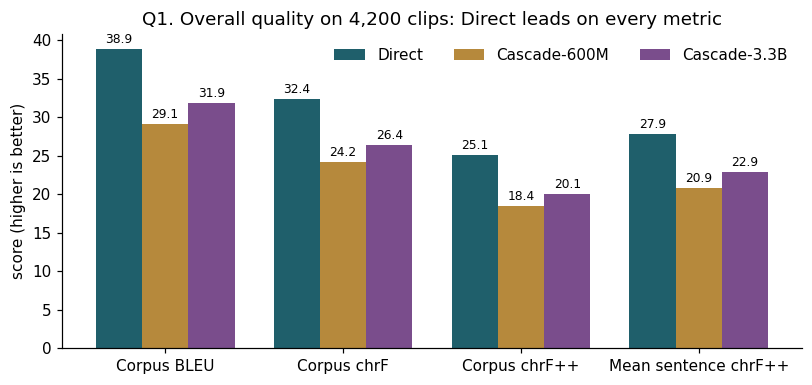

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
metrics = ["Corpus BLEU", "Corpus chrF", "Corpus chrF++", "Mean sentence chrF++"]
x = np.arange(len(metrics)); w = 0.26
for i, s in enumerate(SYSTEMS):
    vals = t1.set_index("System").loc[s, metrics].values
    bars = ax.bar(x + (i - 1) * w, vals, w, label=s, color=COLORS[s])
    ax.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("score (higher is better)")
ax.set_title("Q1. Overall quality on 4,200 clips: Direct leads on every metric")
ax.legend(frameon=False, ncol=3, loc="upper right")
fig_q1 = savefig("q1_overall_scores")

### Explanation

Direct (SeamlessM4T v2-large) scores highest on all four quantities: corpus BLEU 38.86 against 29.11 for Cascade-600M and 31.91 for Cascade-3.3B, corpus chrF++ 25.08 against 18.44 and 20.06, and mean sentence chrF++ 27.86 against 20.86 and 22.87. The ordering Direct, then Cascade-3.3B, then Cascade-600M is the same under every metric.

The paired bootstrap turns those point differences into intervals. After clustering by speaker, Direct leads Cascade-600M by 7.00 mean sentence chrF++ points (95% interval 6.45 to 7.60) and Cascade-3.3B by 4.99 points (4.39 to 5.70). Cascade-3.3B leads Cascade-600M by 2.01 points (1.61 to 2.42). None of the intervals come near zero. The paired Wilcoxon tests agree at both clip and speaker level, with rank-biserial effect sizes of 0.56 and 0.63 for Direct against 600M, 0.43 and 0.51 against 3.3B, and 0.20 and 0.23 for 3.3B against 600M.

I note two things about what this does and does not show. The Whisper front end of the cascades is accurate on this set (mean normalised WER 6.3%, with 70% of clips transcribed without a single word error), so the cascade deficit is not mainly a story of broken transcripts. And the three systems differ in model family, parameter count and training data, so the result ranks these specific systems on this set rather than the two architectures in general.

**Concluding statement for Q1.** On this frozen set, Direct is associated with the highest translation quality on every metric, leading Cascade-3.3B by 4.99 mean sentence chrF++ points (95% speaker-clustered interval 4.39 to 5.70) and Cascade-600M by 7.00 points (6.45 to 7.60); Cascade-3.3B is in turn 2.01 points (1.61 to 2.42) ahead of Cascade-600M.

---
# Q2. Does the ranking hold within every accent?

**Evidence:** Table T2 (corpus chrF++ and corpus BLEU within each accent, recomputed from Patricia's merged table) and the per-accent speaker-clustered gap intervals from Zhitong's `intervals_long.csv`.

In [8]:
rows = []
for accent, g in df.groupby("accent"):
    r = {"Accent": accent}
    for s in SYSTEMS:
        sc = corpus_scores(g, s)
        r[f"chrF++ {s}"] = sc["Corpus chrF++"]
        r[f"BLEU {s}"] = sc["Corpus BLEU"]
    rows.append(r)
t2 = pd.DataFrame(rows)
t2["Direct rank 1 (chrF++)"] = t2[["chrF++ Direct", "chrF++ Cascade-600M", "chrF++ Cascade-3.3B"]].idxmax(axis=1).eq("chrF++ Direct")
t2["Direct rank 1 (BLEU)"] = t2[["BLEU Direct", "BLEU Cascade-600M", "BLEU Cascade-3.3B"]].idxmax(axis=1).eq("BLEU Direct")
show(t2, "T2. Corpus chrF++ and corpus BLEU within each accent group (600 clips each)")

q2_ci = interval_rows("mean_gap", "speaker")
q2_ci = q2_ci[q2_ci["stratum"] != "overall"].copy()
q2_ci["Accent"] = q2_ci["stratum"].map(ACCENT_SHORT)
q2_wide = q2_ci.pivot(index="Accent", columns="comparison", values=["estimate", "ci_low", "ci_high"])
pretty = pd.DataFrame({c: q2_ci[q2_ci["comparison"] == c].set_index("Accent").apply(fmt_ci, axis=1) for c in GAPS}).reset_index()
show(pretty, "Per-accent mean sentence chrF++ gaps with 95% speaker-clustered intervals", floatfmt="s")
print("All per-accent gap intervals exclude zero:", bool(q2_ci["excludes_zero"].all()))

T2. Corpus chrF++ and corpus BLEU within each accent group (600 clips each)
| Accent             |   chrF++ Direct |   BLEU Direct |   chrF++ Cascade-600M |   BLEU Cascade-600M |   chrF++ Cascade-3.3B |   BLEU Cascade-3.3B | Direct rank 1 (chrF++)   | Direct rank 1 (BLEU)   |
|:-------------------|----------------:|--------------:|----------------------:|--------------------:|----------------------:|--------------------:|:-------------------------|:-----------------------|
| England            |           25.18 |         38.51 |                 19.58 |               30.82 |                 20.42 |               32.31 | True                     | True                   |
| Filipino           |           26.09 |         40.68 |                 18.80 |               30.03 |                 21.68 |               34.03 | True                     | True                   |
| Hong Kong          |           25.64 |         39.23 |                 17.67 |               28.09 |                 1

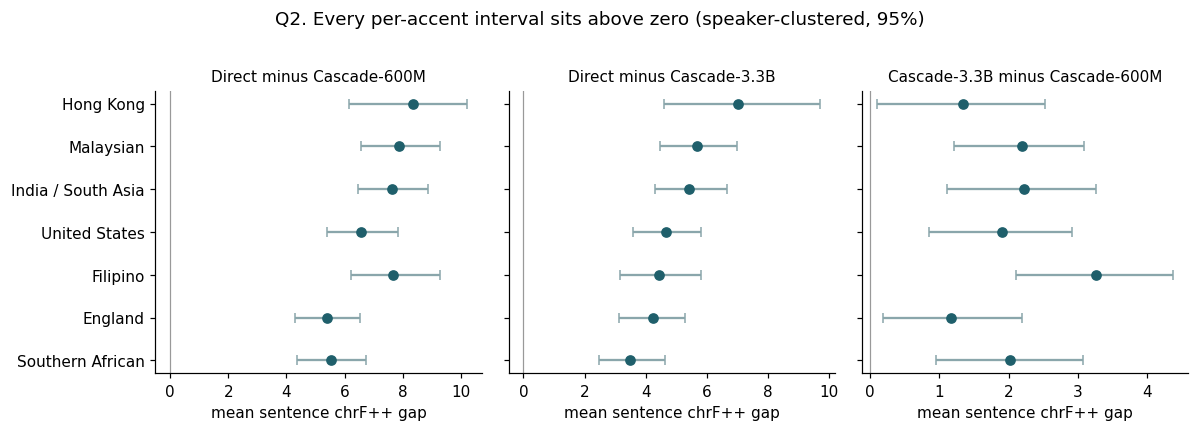

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), sharey=True)
order = q2_ci[q2_ci["comparison"] == "Direct minus Cascade-3.3B"].sort_values("estimate")["Accent"].tolist()
for ax, comp in zip(axes, GAPS):
    d = q2_ci[q2_ci["comparison"] == comp].set_index("Accent").loc[order]
    y = np.arange(len(d))
    ax.errorbar(d["estimate"], y, xerr=[d["estimate"] - d["ci_low"], d["ci_high"] - d["estimate"]],
                fmt="o", color="#1f5f6b", ecolor="#8aa6ab", capsize=3)
    ax.axvline(0, color="#999", lw=0.8)
    ax.set_yticks(y); ax.set_yticklabels(order)
    ax.set_title(comp, fontsize=10)
    ax.set_xlabel("mean sentence chrF++ gap")
fig.suptitle("Q2. Every per-accent interval sits above zero (speaker-clustered, 95%)", y=1.02)
fig_q2 = savefig("q2_per_accent_gaps")

### Explanation

The ranking from Q1 holds in all seven accent groups. Under corpus chrF++ Direct is first in every group, from 24.11 (India / South Asia) to 26.09 (Filipino), with Cascade-3.3B second and Cascade-600M third in each. Corpus BLEU gives the same ordering in every group. Cascade-3.3B improves on Cascade-600M in all seven, which is the within-accent version of the model-scale lift that Q7 looks at more closely.

The intervals confirm that the ordering is not a sampling artefact of any one accent. All 21 per-accent gap intervals (three comparisons times seven accents) exclude zero at the speaker level and again at the clip level. The narrowest Direct lead over Cascade-3.3B is Southern African at 3.50 points (2.47 to 4.64); the widest is Hong Kong English at 7.02 points (4.59 to 9.69). The smallest scale lift is England English at 1.17 points (0.18 to 2.19), where the interval comes closest to zero.

The Hong Kong and Malaysian groups have 41 and 61 pseudonymous speakers respectively against 527 for United States English, which is why their speaker-clustered intervals are wider. The conclusion survives that extra uncertainty.

**Concluding statement for Q2.** The ordering Direct, then Cascade-3.3B, then Cascade-600M holds within every one of the seven accent groups under corpus chrF++, corpus BLEU and the paired mean sentence chrF++ intervals, and every per-accent interval excludes zero.

---
# Q3. How much does accent move each system?

**Evidence:** Accent means per system with speaker-clustered intervals, the between-accent spread (highest accent mean minus lowest) with its interval, and the spread-difference intervals, all from Zhitong's `accent_means_ci.csv`; Kruskal-Wallis on each system's sentence chrF++ by accent and the accent-order Spearman correlations from `tests.csv`.

In [10]:
am = accent_means[(accent_means["statistic"] == "accent_mean") & (accent_means["unit"] == "speaker")].copy()
am["Accent"] = am["accent"].map(ACCENT_SHORT)
q3_means = am.pivot(index="Accent", columns="system", values="estimate")[list(SYSTEMS)].round(2)
q3_rank = am.pivot(index="Accent", columns="system", values="rank_within_system")[list(SYSTEMS)].astype(int)
q3_rank.columns = [f"rank {c}" for c in q3_rank.columns]
show(pd.concat([q3_means, q3_rank], axis=1).reset_index(),
     "Accent means of sentence chrF++ per system (speaker-clustered estimates) and rank within system (1 = best)")

spread = accent_means[(accent_means["statistic"] == "spread_max_minus_min") & (accent_means["unit"] == "speaker")][
    ["system", "accent", "estimate", "ci_low", "ci_high"]].rename(columns={"accent": "max / min accent"})
show(spread, "Between-accent spread (max accent mean minus min accent mean), 95% speaker-clustered interval")

spread_diff = accent_means[(accent_means["statistic"] == "spread_difference") & (accent_means["unit"] == "speaker")][
    ["system", "estimate", "ci_low", "ci_high", "excludes_zero"]]
show(spread_diff, "Difference in spread between systems (negative means the first system has the smaller spread)")

q3_kw = tests[(tests["test"] == "kruskal_wallis") & (tests["target"].str.endswith("sentence chrF++"))][
    ["target", "level", "statistic", "df", "p", "effect_size"]].rename(columns={"statistic": "H", "effect_size": "epsilon_squared"})
show(q3_kw, "Kruskal-Wallis: does each system's sentence chrF++ differ across the seven accents?", floatfmt=".4f")

q3_order = tests[tests["test"] == "accent_order_spearman"][["target", "stratum_b", "statistic"]].rename(
    columns={"stratum_b": "order", "statistic": "spearman_rho"})
show(q3_order, "Agreement of the accent ordering between systems (Spearman on the seven accent means)", floatfmt=".3f")

Accent means of sentence chrF++ per system (speaker-clustered estimates) and rank within system (1 = best)
| Accent             |   Direct |   Cascade-600M |   Cascade-3.3B |   rank Direct |   rank Cascade-600M |   rank Cascade-3.3B |
|:-------------------|---------:|---------------:|---------------:|--------------:|--------------------:|--------------------:|
| England            |    27.88 |          22.47 |          23.64 |             4 |                   1 |                   3 |
| Filipino           |    28.90 |          21.23 |          24.48 |             1 |                   3 |                   1 |
| Hong Kong          |    28.33 |          19.97 |          21.31 |             2 |                   6 |                   7 |
| India / South Asia |    27.40 |          19.77 |          21.99 |             5 |                   7 |                   6 |
| Malaysian          |    28.03 |          20.18 |          22.38 |             3 |                   5 |                   5

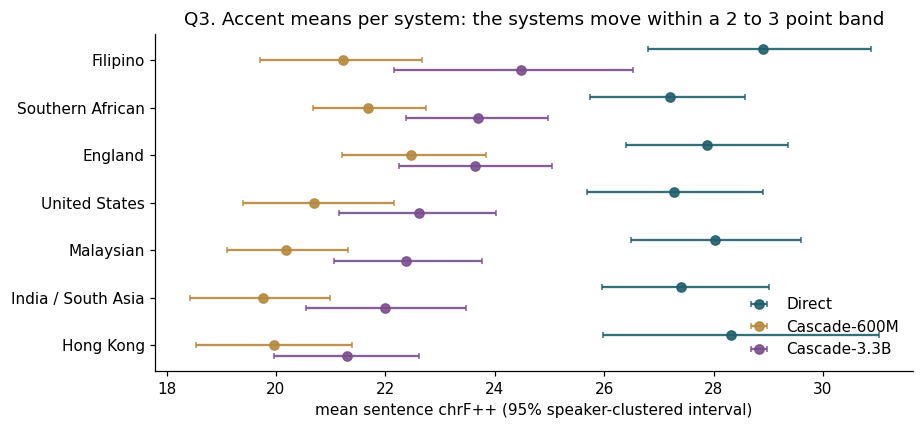

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4))
order = q3_means["Cascade-3.3B"].sort_values(ascending=False).index.tolist()
y = np.arange(len(order))
for i, s in enumerate(SYSTEMS):
    d = am[am["system"] == s].set_index("Accent").loc[order]
    ax.errorbar(d["estimate"], y + (i - 1) * 0.22,
                xerr=[d["estimate"] - d["ci_low"], d["ci_high"] - d["estimate"]],
                fmt="o", color=COLORS[s], ecolor=COLORS[s], alpha=0.9, capsize=2, label=s)
ax.set_yticks(y); ax.set_yticklabels(order); ax.invert_yaxis()
ax.set_xlabel("mean sentence chrF++ (95% speaker-clustered interval)")
ax.set_title("Q3. Accent means per system: the systems move within a 2 to 3 point band")
ax.legend(frameon=False, loc="lower right")
fig_q3 = savefig("q3_accent_means")

### Explanation

Accent moves each system by a small amount relative to the distance between systems. Direct's accent means run from 27.20 (Southern African) to 28.90 (Filipino), a spread of 1.71 points (interval 1.43 to 5.06). Cascade-600M runs from 19.77 (India / South Asia) to 22.47 (England), spread 2.70 (1.95 to 4.74). Cascade-3.3B runs from 21.31 (Hong Kong) to 24.48 (Filipino), spread 3.17 (2.03 to 5.67). Every spread is smaller than Direct's lead over either cascade (4.99 and 7.00 points). The two cascades, however, differ from each other by only 2.01 points, which is less than either cascade's own spread, so on point estimates accent moves each cascade somewhat more than the 600M-to-3.3B upgrade lifts it.

Whether one system is more accent-sensitive than another cannot be settled on this evidence. Direct has the smallest point spread, and the spread-difference intervals all include zero: Direct minus Cascade-3.3B spread is −1.47 with interval −2.62 to +1.63, Direct minus Cascade-600M is −0.99 (−2.34 to +2.28). The Kruskal-Wallis tests point the same way. Accent is associated with Cascade-600M's scores at both levels (clip p = 0.006, speaker p = 0.041) and with Cascade-3.3B's at clip level (p = 0.006) but not at speaker level (p = 0.168), while Direct's scores show no accent association at either level (p = 0.264 and 0.185). The effect sizes are all tiny (epsilon squared at most 0.008).

The accent orderings disagree between Direct and the cascades. Hong Kong and Malaysian are Direct's second and third groups and sit fifth to seventh for both cascades; Southern African is Direct's lowest group and second for both cascades; England is first for Cascade-600M and fourth for Direct. Filipino is the exception that ranks high everywhere (first for Direct and Cascade-3.3B, third for Cascade-600M). The Spearman between Direct's ordering and Cascade-3.3B's is −0.07, and 0.82 between the two cascades. So the two architectures do not share one accent-difficulty profile on this set. I return to this in Q8, because the action plan expected a shared ordering as a marker of shared acoustic difficulty, and the data does not show one.

**Concluding statement for Q3.** Accent is associated with a between-accent spread of 1.71 points for Direct, 2.70 for Cascade-600M and 3.17 for Cascade-3.3B in mean sentence chrF++, with Direct showing no accent association on the Kruskal-Wallis test; the spread-difference intervals include zero, so the data does not establish that any system is more accent-robust than another on the spread measure, and the accent orderings of Direct and the cascades differ.

---
# Q4. Does the Direct minus Cascade gap depend on accent?

**Evidence:** Kruskal-Wallis on the per-clip and per-speaker gaps by accent, Dunn pairwise comparisons with Holm correction, Cliff's delta, and the per-accent Wilcoxon tests, all from Zhitong's `tests.csv`. The per-accent gap estimates themselves are the Q2 intervals.

In [12]:
gap_targets = list(GAPS)
q4_kw = tests[(tests["test"] == "kruskal_wallis") & (tests["target"].isin(gap_targets))][
    ["target", "level", "statistic", "df", "p", "effect_size"]].rename(columns={"statistic": "H", "effect_size": "epsilon_squared"})
show(q4_kw, "Kruskal-Wallis: does the gap differ across accents?", floatfmt=".4f")

dunn = tests[(tests["test"] == "dunn_holm") & (tests["target"].isin(gap_targets[:2]))].copy()
dunn["pair"] = dunn["stratum_a"].map(ACCENT_SHORT) + " vs " + dunn["stratum_b"].map(ACCENT_SHORT)
q4_dunn = dunn[dunn["p_holm"] < 0.05][["target", "level", "pair", "p_holm", "effect_size"]].rename(
    columns={"effect_size": "cliffs_delta"})
show(q4_dunn, "Dunn pairwise comparisons that survive Holm correction (p_holm < 0.05)", floatfmt=".4f")
print("Largest |Cliff's delta| among all Dunn pairs at clip level:",
      round(dunn[dunn["level"] == "clip"]["effect_size"].abs().max(), 3),
      "| at speaker level:", round(dunn[dunn["level"] == "speaker"]["effect_size"].abs().max(), 3))

wx = tests[(tests["test"] == "wilcoxon_signed_rank") & (tests["target"].isin(gap_targets[:2]))
           & (tests["stratum_a"] != "overall") & (tests["level"] == "speaker")].copy()
wx["Accent"] = wx["stratum_a"].map(ACCENT_SHORT)
q4_wx = wx.pivot(index="Accent", columns="target", values="effect_size").round(3).reset_index()
show(q4_wx, "Per-accent paired Wilcoxon (speaker level): rank-biserial effect size, all p < 0.001", floatfmt=".3f")

Kruskal-Wallis: does the gap differ across accents?
| target                          | level   |       H |     df |      p |   epsilon_squared |
|:--------------------------------|:--------|--------:|-------:|-------:|------------------:|
| Direct minus Cascade-600M       | clip    | 21.4902 | 6.0000 | 0.0015 |            0.0051 |
| Direct minus Cascade-3.3B       | clip    | 15.3481 | 6.0000 | 0.0177 |            0.0037 |
| Cascade-3.3B minus Cascade-600M | clip    | 10.1382 | 6.0000 | 0.1190 |            0.0024 |
| Direct minus Cascade-600M       | speaker | 21.4440 | 6.0000 | 0.0015 |            0.0135 |
| Direct minus Cascade-3.3B       | speaker | 17.1596 | 6.0000 | 0.0087 |            0.0108 |
| Cascade-3.3B minus Cascade-600M | speaker |  9.0967 | 6.0000 | 0.1682 |            0.0057 |

Dunn pairwise comparisons that survive Holm correction (p_holm < 0.05)
| target                    | level   | pair                          |   p_holm |   cliffs_delta |
|:----------------------

### Explanation

The gap is positive everywhere (Q2) and its size differs by accent, with a small effect. For Direct minus Cascade-600M the Kruskal-Wallis test rejects equal gaps at both levels (clip H = 21.5, p = 0.0015; speaker H = 21.4, p = 0.0015). For Direct minus Cascade-3.3B it does too, less firmly (clip p = 0.018; speaker p = 0.0087). Epsilon squared is 0.005 and 0.004 at clip level and 0.014 and 0.011 at speaker level, so accent explains about one percent of the variation in the gap.

Few accent pairs differ once Holm correction is applied across the 21 pairs. At the speaker level, 2 of 21 pairs survive for Direct minus Cascade-600M: England against Malaysian (adjusted p = 0.005; gaps 5.41 against 7.86) and Malaysian against United States (adjusted p = 0.050). For Direct minus Cascade-3.3B, 1 of 21 survives: Malaysian against United States (adjusted p = 0.035). The Cliff's delta magnitudes of these three surviving pairs are 0.23 to 0.30. The clip-level tests, which treat repeated clips from a speaker as independent, give a similar picture: England against Hong Kong and England against Malaysian for Cascade-600M, and Hong Kong against Southern African for Cascade-3.3B, with Cliff's delta below 0.13 for every pair. Against Cascade-600M, Direct's advantage is wider on the Hong Kong, Malaysian, Filipino and India / South Asia groups, which are the four groups with the highest Whisper WER in Q6, and narrower on United States, Southern African and England English, the three lowest-WER groups. Against Cascade-3.3B the same split holds except for Filipino, which drops to fifth because the 3.3B lift is largest there (Q7).

Within every accent the gap itself is large and reliable: the speaker-level Wilcoxon rank-biserial runs from 0.53 (England) to 0.93 (Malaysian) for Direct minus Cascade-600M and from 0.39 (United States) to 0.91 (Malaysian) for Direct minus Cascade-3.3B, all with p < 0.001.

**Concluding statement for Q4.** The Direct minus Cascade gap is associated with accent (Kruskal-Wallis p = 0.0015 against Cascade-600M and p = 0.0087 against Cascade-3.3B at speaker level) with small effect sizes (epsilon squared about 0.01; only 2 and 1 of 21 accent pairs survive Holm correction at speaker level, with Cliff's delta 0.23 to 0.30); against Cascade-600M it is widest on the four highest-WER groups (Hong Kong, Malaysian, Filipino, India / South Asia) and narrowest on the three lowest-WER groups, and it stays positive in every group.

---
# Q5. How much does `<unk>` output depress Direct's score?

The action plan phrased this as "how much of the Direct deficit is `<unk>`". The data reversed the direction (Direct leads), so I ask the question the data allows: how much lower is Direct's score because 508 of its 4,200 outputs contain the literal string `<unk>`, and does removing those clips change the comparison?

**Evidence:** Table T5 (`<unk>` rate by accent, with Arizona's speaker-level intervals and logistic test from `unk_analysis/results/accent/`), Direct and both cascades scored on all 4,200 clips, on the 3,692 `<unk>`-free clips and on the 508 affected clips (recomputed here), and a **new** paired bootstrap on the `<unk>`-free subset. Notebook 09's code writes `intervals_unk_free.csv` but that file was never tracked, so I recompute it here with the same resampler, seed and resample count that Zhitong used. Before using it, the code checks that it reproduces Zhitong's tracked overall intervals on the full set to six decimal places.

In [13]:
t5 = pd.read_csv("unk_analysis/results/accent/unk_by_accent_ci.csv")
show(t5, "T5. Direct literal <unk> rate by accent, 95% speaker-bootstrap intervals (Arizona, accent_rate.py)")
logit = pd.read_csv("unk_analysis/results/accent/unk_logit.csv")
show(logit, "Logistic regression of <unk> on accent: joint Wald test for the six accent terms", floatfmt=".4f")

free = df[~df["direct_has_unk"]]
affected = df[df["direct_has_unk"]]
subset_scores = pd.concat([
    scores_table(df).assign(Subset="All clips"),
    scores_table(free).assign(Subset="<unk>-free clips"),
    scores_table(affected).assign(Subset="<unk> clips only"),
])[["Subset", "System", "N", "Corpus BLEU", "Corpus chrF", "Corpus chrF++", "Mean sentence chrF++"]]
show(subset_scores, "All three systems scored on the full set, the <unk>-free subset and the affected subset")
subset_scores.to_csv(OUT / "table_q5_scores_by_unk_subset.csv", index=False)

direct_all = subset_scores[(subset_scores.Subset == "All clips") & (subset_scores.System == "Direct")].iloc[0]
direct_free = subset_scores[(subset_scores.Subset == "<unk>-free clips") & (subset_scores.System == "Direct")].iloc[0]
print(f"Direct corpus chrF++ rises by {direct_free['Corpus chrF++'] - direct_all['Corpus chrF++']:.2f} points "
      f"and corpus BLEU by {direct_free['Corpus BLEU'] - direct_all['Corpus BLEU']:.2f} points when the 508 affected clips are removed.")
print("Mean per-clip gaps on each subset (Direct minus Cascade-3.3B):",
      f"all {df['gap_direct_33b'].mean():.2f}, unk-free {free['gap_direct_33b'].mean():.2f}, unk-only {affected['gap_direct_33b'].mean():.2f}")

T5. Direct literal <unk> rate by accent, 95% speaker-bootstrap intervals (Arizona, accent_rate.py)
| accent                |   n_clips |   n_speakers |   n_unk |   unk_rate_pct |   ci_low_pct |   ci_high_pct |
|:----------------------|----------:|-------------:|--------:|---------------:|-------------:|--------------:|
| All accents           |      4200 |         1586 |     508 |          12.10 |        11.11 |         13.14 |
| England English       |       600 |          398 |      81 |          13.50 |        10.56 |         16.27 |
| Filipino              |       600 |           72 |      65 |          10.83 |         8.49 |         13.15 |
| Hong Kong English     |       600 |           41 |      62 |          10.33 |         7.22 |         13.69 |
| India and South Asia  |       600 |          356 |      80 |          13.33 |        10.64 |         16.18 |
| Malaysian English     |       600 |           61 |      78 |          13.00 |         9.92 |         16.18 |
| Southern Af

All three systems scored on the full set, the <unk>-free subset and the affected subset
| Subset           | System       |    N |   Corpus BLEU |   Corpus chrF |   Corpus chrF++ |   Mean sentence chrF++ |
|:-----------------|:-------------|-----:|--------------:|--------------:|----------------:|-----------------------:|
| All clips        | Direct       | 4200 |         38.86 |         32.38 |           25.08 |                  27.86 |
| All clips        | Cascade-600M | 4200 |         29.11 |         24.23 |           18.44 |                  20.86 |
| All clips        | Cascade-3.3B | 4200 |         31.91 |         26.36 |           20.06 |                  22.87 |
| <unk>-free clips | Direct       | 3692 |         40.67 |         33.91 |           26.32 |                  29.08 |
| <unk>-free clips | Cascade-600M | 3692 |         30.21 |         25.07 |           19.10 |                  21.58 |
| <unk>-free clips | Cascade-3.3B | 3692 |         33.07 |         27.27 |           2

In [14]:
# Speaker-clustered, accent-stratified paired bootstrap on the <unk>-free subset.
# This is Zhitong's StratifiedBoot from 09_statistical_analysis.ipynb, reduced to what Q5 needs.
class StratifiedBoot:
    def __init__(self, frame, value_cols, unit, B, seed):
        self.cols = list(value_cols)
        self.accents = sorted(frame["accent"].unique())
        rng = np.random.default_rng(seed)
        self.num, self.den = {}, {}
        for a in self.accents:
            d = frame[frame["accent"] == a]
            key = d["sample_id"].to_numpy() if unit == "speaker" else np.arange(len(d))
            codes, _ = pd.factorize(key)
            G = codes.max() + 1
            S = np.zeros((G, len(self.cols)))
            np.add.at(S, codes, d[self.cols].to_numpy())
            n = np.bincount(codes, minlength=G).astype(float)
            idx = rng.integers(0, G, size=(B, G))
            self.num[a] = S[idx].sum(axis=1)
            self.den[a] = n[idx].sum(axis=1)
    def means(self, accent=None):
        if accent is None:
            return sum(self.num.values()) / sum(self.den.values())[:, None]
        return self.num[accent] / self.den[accent][:, None]

def paired_gap_intervals(frame, unit="speaker", B=N_BOOT, seed=SEED, label=""):
    cols = list(GAPS.values())
    bt = StratifiedBoot(frame, cols, unit, B, seed)
    rows = []
    for stratum in ["overall"] + bt.accents:
        d = frame if stratum == "overall" else frame[frame["accent"] == stratum]
        M = bt.means(None if stratum == "overall" else stratum)
        for j, (name, col) in enumerate(GAPS.items()):
            lo, hi = np.percentile(M[:, j], [2.5, 97.5])
            rows.append(dict(subset=label, comparison=name, stratum=stratum, unit=unit,
                             n_clips=len(d), n_speakers=d["sample_id"].nunique(),
                             estimate=d[col].mean(), ci_low=lo, ci_high=hi, excludes_zero=bool(lo > 0 or hi < 0)))
    return pd.DataFrame(rows)

# Check: on all 4,200 clips this resampler must reproduce Zhitong's tracked overall speaker intervals exactly.
check = paired_gap_intervals(df, "speaker").query("stratum == 'overall'").set_index("comparison")
tracked = interval_rows("mean_gap", "speaker", "overall").set_index("comparison")
assert np.allclose(check.loc[tracked.index, ["ci_low", "ci_high"]].to_numpy(),
                   tracked[["ci_low", "ci_high"]].to_numpy(), atol=1e-6)
print("Resampler check passed: reproduces intervals_long.csv overall speaker intervals exactly.")

unk_free_iv = paired_gap_intervals(free, "speaker", label="unk-free clips")
unk_free_iv["n_unk_dropped"] = int(df["direct_has_unk"].sum())
unk_free_iv.to_csv(OUT / "intervals_unk_free.csv", index=False)

compare = pd.concat([
    interval_rows("mean_gap", "speaker").assign(subset="all clips"),
    unk_free_iv,
])
compare["stratum"] = compare["stratum"].replace(ACCENT_SHORT)
q5_compare = compare[compare["comparison"] != "Cascade-3.3B minus Cascade-600M"].copy()
q5_compare["estimate [95% CI]"] = q5_compare.apply(fmt_ci, axis=1)
q5_wide = q5_compare.pivot(index=["comparison", "stratum"], columns="subset", values="estimate [95% CI]").reset_index()
show(q5_wide, "Direct minus Cascade gaps, all clips versus <unk>-free clips (speaker-clustered, seed 760, 1,000 resamples)", floatfmt="s")
print("Saved:", OUT / "intervals_unk_free.csv")

Resampler check passed: reproduces intervals_long.csv overall speaker intervals exactly.
Direct minus Cascade gaps, all clips versus <unk>-free clips (speaker-clustered, seed 760, 1,000 resamples)
| comparison                | stratum            | all clips             | unk-free clips        |
|:--------------------------|:-------------------|:----------------------|:----------------------|
| Direct minus Cascade-3.3B | England            | +4.24 [+3.11, +5.30]  | +4.59 [+3.28, +5.85]  |
| Direct minus Cascade-3.3B | Filipino           | +4.42 [+3.17, +5.79]  | +4.80 [+3.41, +6.31]  |
| Direct minus Cascade-3.3B | Hong Kong          | +7.02 [+4.59, +9.69]  | +7.72 [+4.89, +10.35] |
| Direct minus Cascade-3.3B | India / South Asia | +5.41 [+4.29, +6.66]  | +5.96 [+4.75, +7.16]  |
| Direct minus Cascade-3.3B | Malaysian          | +5.66 [+4.45, +6.97]  | +6.08 [+4.51, +7.67]  |
| Direct minus Cascade-3.3B | Southern African   | +3.50 [+2.47, +4.64]  | +3.89 [+2.76, +5.12]  |
| Direct mi

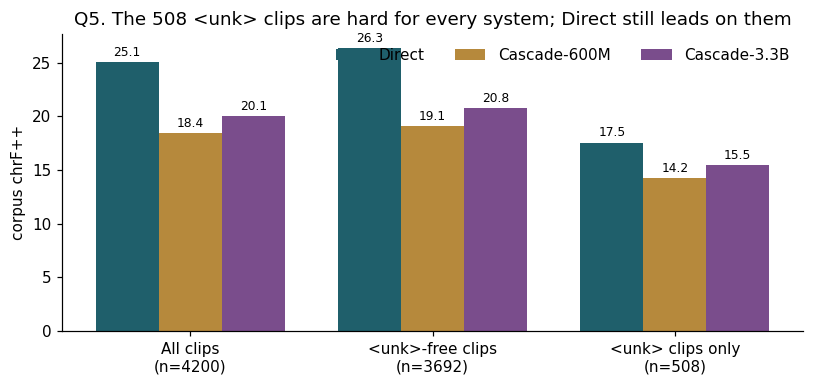

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
subs = ["All clips", "<unk>-free clips", "<unk> clips only"]
x = np.arange(len(subs)); w = 0.26
for i, s in enumerate(SYSTEMS):
    vals = [subset_scores[(subset_scores.Subset == sub) & (subset_scores.System == s)]["Corpus chrF++"].iloc[0] for sub in subs]
    bars = ax.bar(x + (i - 1) * w, vals, w, label=s, color=COLORS[s])
    ax.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels([f"{s}\n(n={n})" for s, n in zip(subs, [4200, 3692, 508])])
ax.set_ylabel("corpus chrF++")
ax.set_title("Q5. The 508 <unk> clips are hard for every system; Direct still leads on them")
ax.legend(frameon=False, ncol=3)
fig_q5 = savefig("q5_unk_subsets")

### Explanation

The `<unk>` marker appears in 508 Direct outputs (12.1%, interval 11.1% to 13.1%) and in no cascade output. Its rate is flat across accents, from 10.3% (Hong Kong) to 13.5% (England); the intervals overlap and Arizona's speaker-clustered logistic model gives p = 0.50 for the joint accent terms. The marker is therefore not an accent-sensitivity mechanism on this set.

Its cost to Direct is modest. Removing the 508 affected clips lifts Direct's corpus chrF++ from 25.08 to 26.32 (1.24 points) and corpus BLEU from 38.86 to 40.67 (about 1.8 points). Two further observations keep that number in proportion. First, the affected clips are hard for all three systems: on those 508 clips Cascade-3.3B scores 15.46 corpus chrF++ against its own 20.06 overall, so the content that trips Direct into `<unk>` is content the cascades also translate poorly. Second, Direct still leads on the affected clips (17.55 against 15.46 corpus chrF++; mean per-clip gap +1.86 against 3.3B), which means the `<unk>` outputs are partially correct translations with a marker in them, not blanks.

Removing the affected clips widens Direct's lead rather than narrowing it: the speaker-clustered gap against Cascade-3.3B moves from +4.99 (4.39 to 5.70) on all clips to +5.42 on the `<unk>`-free subset, and against Cascade-600M from +7.00 to +7.50. Every per-accent interval stays above zero on the subset. The `<unk>` behaviour is a real Direct error mode, worth about 1.2 corpus chrF++ points and worth fixing (Q9), and it does not account for any part of the direction or the accent pattern of the gap.

**Concluding statement for Q5.** Literal `<unk>` output affects 12.1% of Direct's translations at a flat rate across accents (logistic p = 0.50) and depresses Direct's corpus chrF++ by 1.24 points (25.08 against 26.32 on the 3,692 clean clips); on the clean subset Direct's lead widens to +5.42 over Cascade-3.3B and +7.50 over Cascade-600M with all per-accent intervals above zero, so `<unk>` is associated with a small, uniform penalty and not with the gap's direction or its accent dependence.

---
# Q6. Does Whisper WER predict cascade quality?

**Evidence:** Table T4 (mean per-clip normalised WER by accent, from my base evaluation as carried into Patricia's table), Zhitong's Spearman table with speaker-cluster bootstrap intervals, and a **new** split of every clip by whether Whisper made any word error.

In [16]:
t4 = df.groupby("accent").agg(mean_wer=("wer_norm", "mean"), std_wer=("wer_norm", "std"),
                              share_zero_wer=("wer_norm", lambda s: (s == 0).mean()), n=("id", "count")).reset_index()
t4 = t4.sort_values("mean_wer")
show(t4, "T4. Normalised Whisper WER by accent (mean of per-clip WER; identical for both cascades)", floatfmt=".4f")

sp = spearman[spearman["unit"] == "speaker"].copy()
sp["stratum"] = sp["stratum"].replace(ACCENT_SHORT)
sp["rho [95% CI]"] = sp.apply(lambda r: f"{r['rho']:+.3f} [{r['ci_low']:+.3f}, {r['ci_high']:+.3f}]", axis=1)
q6_sp = sp.pivot(index="stratum", columns="y", values="rho [95% CI]").reset_index()
show(q6_sp, "Spearman rho between normalised WER and the outcome, speaker-cluster bootstrap 95% intervals", floatfmt="s")
print("All Spearman intervals exclude zero:", bool(sp["excludes_zero"].all()))

split = df.assign(asr_error=np.where(df["wer_norm"] > 0, "WER > 0", "WER = 0")).groupby("asr_error").agg(
    n=("id", "count"),
    direct=("chrfpp_direct", "mean"), cascade_600m=("chrfpp_600m", "mean"), cascade_33b=("chrfpp_33b", "mean"),
    gap_direct_600m=("gap_direct_600m", "mean"), gap_direct_33b=("gap_direct_33b", "mean")).reset_index()
show(split, "Mean sentence chrF++ by whether Whisper made any word error on the clip")
split.to_csv(OUT / "table_q6_scores_by_asr_error.csv", index=False)

T4. Normalised Whisper WER by accent (mean of per-clip WER; identical for both cascades)
| accent             |   mean_wer |   std_wer |   share_zero_wer |   n |
|:-------------------|-----------:|----------:|-----------------:|----:|
| United States      |     0.0429 |    0.1023 |           0.7717 | 600 |
| England            |     0.0457 |    0.0997 |           0.7467 | 600 |
| Southern African   |     0.0510 |    0.1045 |           0.7350 | 600 |
| Filipino           |     0.0648 |    0.1204 |           0.6733 | 600 |
| Hong Kong          |     0.0756 |    0.1574 |           0.7117 | 600 |
| Malaysian          |     0.0789 |    0.1360 |           0.6383 | 600 |
| India / South Asia |     0.0836 |    0.1673 |           0.6433 | 600 |

Spearman rho between normalised WER and the outcome, speaker-cluster bootstrap 95% intervals
| stratum            | Cascade-3.3B sentence chrF++   | Cascade-600M sentence chrF++   | gap Direct minus Cascade-3.3B   | gap Direct minus Cascade-600M   |
|:-

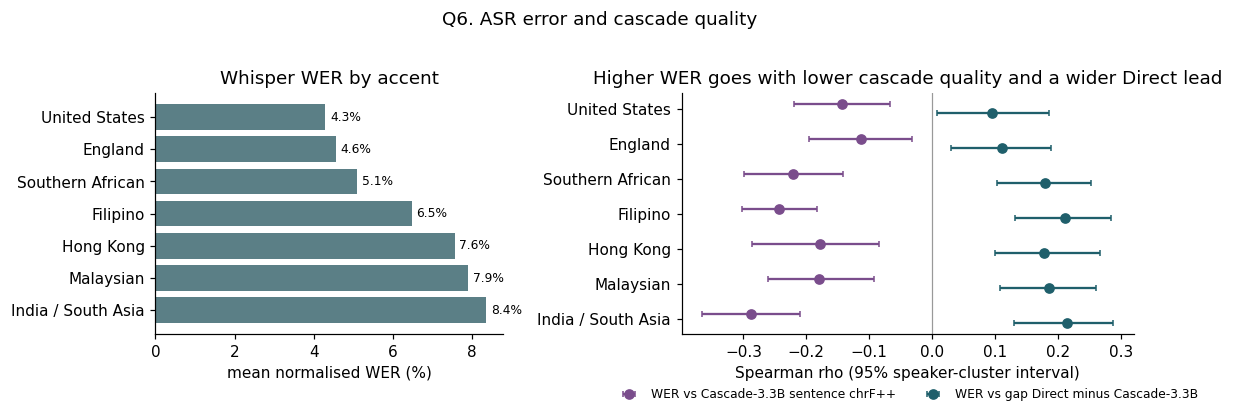

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.3]})
ax = axes[0]
bars = ax.barh(t4["accent"], t4["mean_wer"] * 100, color="#5b7f86")
ax.bar_label(bars, fmt="%.1f%%", fontsize=8, padding=3)
ax.invert_yaxis(); ax.set_xlabel("mean normalised WER (%)")
ax.set_title("Whisper WER by accent")
ax = axes[1]
d = sp[sp["stratum"] != "overall"]
ys = ["Cascade-3.3B sentence chrF++", "gap Direct minus Cascade-3.3B"]
order = t4["accent"].tolist()
yy = np.arange(len(order))
for i, (yname, col) in enumerate(zip(ys, ["#7a4d8c", "#1f5f6b"])):
    dd = d[d["y"] == yname].set_index("stratum").loc[order]
    ax.errorbar(dd["rho"], yy + (i - 0.5) * 0.25, xerr=[dd["rho"] - dd["ci_low"], dd["ci_high"] - dd["rho"]],
                fmt="o", color=col, ecolor=col, capsize=2, label=f"WER vs {yname}")
ax.axvline(0, color="#999", lw=0.8)
ax.set_yticks(yy); ax.set_yticklabels(order); ax.invert_yaxis()
ax.set_xlabel("Spearman rho (95% speaker-cluster interval)")
ax.set_title("Higher WER goes with lower cascade quality and a wider Direct lead")
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)
fig.suptitle("Q6. ASR error and cascade quality", y=1.02)
fig_q6 = savefig("q6_wer_and_spearman")

### Explanation

Yes, weakly, and in every accent. Overall Spearman rho between normalised WER and cascade sentence chrF++ is −0.188 (interval −0.216 to −0.160) for Cascade-600M and −0.196 (−0.226 to −0.166) for Cascade-3.3B. The association is strongest in the India / South Asia group (−0.29 for 3.3B) and the Filipino group (−0.27 for 600M) and weakest in England and United States English (about −0.11 to −0.14), yet all 14 per-accent intervals exclude zero. WER also has a positive association with the Direct minus Cascade gap (+0.133 against 600M, +0.174 against 3.3B): the worse Whisper does on a clip, the further Direct pulls ahead on it.

A rank correlation of −0.2 is small because most clips have no ASR error at all. Splitting on that fact makes the mechanism visible. On the 2,952 clips Whisper transcribed perfectly (70.3%), Cascade-3.3B averages 24.82 sentence chrF++ and Direct 28.43, a gap of 3.61. On the 1,248 clips with at least one word error, Cascade-3.3B drops to 18.27 while Direct holds at 26.50, and the gap widens to 8.24. Any ASR error costs the cascades about six chrF++ points on average; Direct, which has no transcript to corrupt, loses about two on the same clips, which is the shared acoustic difficulty of those clips showing through.

The accent pattern follows directly. The four groups with the highest WER (India / South Asia 8.4%, Malaysian 7.9%, Hong Kong 7.6%, Filipino 6.5%) are the four groups where the cascades rank lowest in Q3 and where Direct's lead is widest in Q4. WER is a transcript diagnostic, so this remains an association across clips; nothing here intervenes on the transcript.

**Concluding statement for Q6.** Whisper WER is associated with lower cascade quality (Spearman rho −0.19 to −0.20 overall, intervals excluding zero in all seven accents) and with a wider Direct lead (rho +0.13 to +0.17); clips with any ASR error score about six sentence chrF++ points lower for the cascades, and even on the 70% of clips with perfect transcripts Direct still leads Cascade-3.3B by 3.61 points, so ASR error explains part of the gap and most of its accent dependence, and not the gap itself.

---
# Q7. Does the larger MT model change the accent picture or only the level?

**Evidence:** The Cascade-3.3B minus Cascade-600M gap by accent with speaker-clustered intervals (`intervals_long.csv`), Kruskal-Wallis and Dunn on that gap (`tests.csv`), the spread-difference interval between the two cascades and the accent-order Spearman between them (`accent_means_ci.csv`, `tests.csv`). Both cascades use identical Whisper transcripts (Patricia's check in notebook 08 found 0 differences in 4,200), so this comparison isolates the translation stage.

In [18]:
q7 = interval_rows("mean_gap", "speaker")
q7 = q7[q7["comparison"] == "Cascade-3.3B minus Cascade-600M"].copy()
q7["stratum"] = q7["stratum"].replace(ACCENT_SHORT)
show(q7[["stratum", "n_speakers", "estimate", "ci_low", "ci_high", "excludes_zero"]],
     "Cascade-3.3B minus Cascade-600M, mean sentence chrF++, speaker-clustered 95% intervals")

q7_kw = tests[(tests["test"] == "kruskal_wallis") & (tests["target"] == "Cascade-3.3B minus Cascade-600M")][
    ["level", "statistic", "df", "p", "effect_size"]].rename(columns={"statistic": "H", "effect_size": "epsilon_squared"})
show(q7_kw, "Kruskal-Wallis: does the scale lift differ across accents?", floatfmt=".4f")
dunn7 = tests[(tests["test"] == "dunn_holm") & (tests["target"] == "Cascade-3.3B minus Cascade-600M")]
print("Dunn pairs with p_holm < 0.05 for the scale lift:", int((dunn7["p_holm"] < 0.05).sum()),
      "| smallest p_holm:", round(dunn7["p_holm"].min(), 3))

show(spread_diff[spread_diff["system"] == "spread Cascade-3.3B minus Cascade-600M"],
     "Between-accent spread, Cascade-3.3B minus Cascade-600M")
show(q3_order[q3_order["target"] == "Cascade-600M vs Cascade-3.3B"], "Accent ordering agreement between the two cascades", floatfmt=".3f")

Cascade-3.3B minus Cascade-600M, mean sentence chrF++, speaker-clustered 95% intervals
| stratum            |   n_speakers |   estimate |   ci_low |   ci_high | excludes_zero   |
|:-------------------|-------------:|-----------:|---------:|----------:|:----------------|
| overall            |         1586 |       2.01 |     1.61 |      2.42 | True            |
| England            |          398 |       1.17 |     0.18 |      2.19 | True            |
| Filipino           |           72 |       3.25 |     2.11 |      4.37 | True            |
| Hong Kong          |           41 |       1.34 |     0.09 |      2.52 | True            |
| India / South Asia |          356 |       2.22 |     1.11 |      3.25 | True            |
| Malaysian          |           61 |       2.20 |     1.21 |      3.09 | True            |
| Southern African   |          131 |       2.02 |     0.96 |      3.07 | True            |
| United States      |          527 |       1.91 |     0.84 |      2.92 | True       

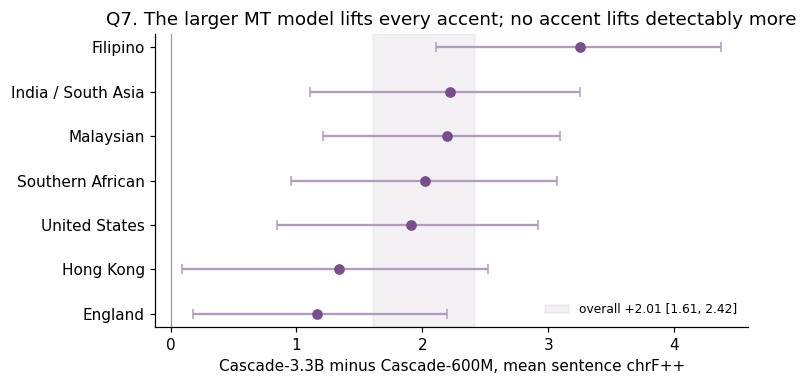

In [19]:
fig, ax = plt.subplots(figsize=(7, 3.6))
d = q7[q7["stratum"] != "overall"].sort_values("estimate")
y = np.arange(len(d))
ax.errorbar(d["estimate"], y, xerr=[d["estimate"] - d["ci_low"], d["ci_high"] - d["estimate"]],
            fmt="o", color="#7a4d8c", ecolor="#b39bc0", capsize=3)
ov = q7[q7["stratum"] == "overall"].iloc[0]
ax.axvspan(ov["ci_low"], ov["ci_high"], color="#7a4d8c", alpha=0.08, label=f"overall {ov['estimate']:+.2f} [{ov['ci_low']:.2f}, {ov['ci_high']:.2f}]")
ax.axvline(0, color="#999", lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(d["stratum"])
ax.set_xlabel("Cascade-3.3B minus Cascade-600M, mean sentence chrF++")
ax.set_title("Q7. The larger MT model lifts every accent; no accent lifts detectably more")
ax.legend(frameon=False, loc="lower right", fontsize=8)
fig_q7 = savefig("q7_scale_lift")

### Explanation

The larger translation model moves the level and leaves the accent picture close to where it was. Cascade-3.3B is ahead of Cascade-600M by 2.01 mean sentence chrF++ points overall (1.61 to 2.42) and in every accent, from 1.17 in England English (0.18 to 2.19) to 3.25 in Filipino (2.11 to 4.37). The Kruskal-Wallis test does not reject an equal lift across accents (clip p = 0.119, speaker p = 0.168), no Dunn pair survives Holm correction, and the spread-difference interval between the two cascades, +0.47 (−1.24 to +2.65), includes zero. The two cascades also agree on which accents are easy and which are hard (Spearman 0.82 on the seven accent means), as they should when they share every transcript.

The point estimates do lean in one direction. The lift is largest for Filipino, India / South Asia and Malaysian English and smallest for England English, and the Q6 split shows why that would be: on clips with ASR errors, both cascades score low and the bigger model has more room to recover meaning from an imperfect transcript. That lean is inside sampling noise on this evidence. A 5.5-fold increase in MT parameters recovers about 2 of the 7 points separating Cascade-600M from Direct; the remaining 5-point lead over Cascade-3.3B, and its accent dependence, belong to something other than MT capacity.

**Concluding statement for Q7.** Scaling the MT stage from 600M to 3.3B parameters is associated with a uniform lift of about 2 mean sentence chrF++ points (overall +2.01, interval 1.61 to 2.42; positive in all seven accents; Kruskal-Wallis p = 0.12 and 0.17 for accent dependence; spread-difference interval including zero), so it changes the level and not the accent picture, and it closes less than a third of the Cascade-600M deficit to Direct.

---
# Q8. What are the probable root causes of the gaps?

The action plan named four candidates: `<unk>` generation on proper nouns, ASR errors carried into the cascade, acoustic difficulty shared by both systems, and MT capacity. Q5 to Q7 already weigh three of them. Here I add the evidence the plan asked for that nobody had produced yet, a **new** audit of the worst ten clips per accent per system, and I bring in Arizona's `<unk>` analysis, which changed what the first candidate looks like.

**Evidence:** Q5 to Q7 above; `unk_analysis/results/word_type/`, `word_removal/`, `decode_probs/` and `text_only/` (Arizona); the worst-clip audit computed here from Patricia's merged table and saved to `runs/synthesis_results/worst_clips_by_accent_system.csv`.

In [20]:
wt = pd.read_csv("unk_analysis/results/word_type/unk_wordtype_rates.csv")
show(wt, "Direct <unk> rate by sentence feature (Arizona, word_type.py)")
text_only = json.load(open("unk_analysis/results/text_only/run_summary_unk_extra_1_text.json"))
print(f"Text-only input (same model, same revision): <unk> in {text_only['text_ref_unk_rate_pct']:.1f}% of outputs; "
      f"P(text <unk> | speech <unk>) = {text_only['p_text_unk_given_speech_unk']:.3f}")
occ = pd.read_csv("unk_analysis/results/word_removal/occlusion_sentences.csv")
occ_unk = occ[occ["has_unk_original"] == True]
print(f"Word removal on {len(occ_unk)} <unk> sentences: removing the most influential word clears the marker in "
      f"{(occ_unk['unk_after_top_removed'] == False).mean():.1%}; removing a random content word clears it in "
      f"{(occ_unk['unk_after_random_removed'] == False).mean():.1%}")
trig = pd.read_csv("unk_analysis/results/word_removal/unk_trigger_summary.csv")
show(trig.head(6), "Trigger-word analysis, first rows (Arizona, trigger_words.py)", floatfmt=".3f")

Direct <unk> rate by sentence feature (Arizona, word_type.py)
| feature                       | level             |   n_clips |   n_unk |   unk_rate_pct |
|:------------------------------|:------------------|----------:|--------:|---------------:|
| has proper noun (spaCy PROPN) | 0                 |      3073 |     372 |          12.10 |
| has proper noun (spaCy PROPN) | 1                 |      1127 |     136 |          12.10 |
| has named entity              | 0                 |      3212 |     394 |          12.30 |
| has named entity              | 1                 |       988 |     114 |          11.50 |
| rarest content word (Zipf)    | <=2.5 (very rare) |       262 |      82 |          31.30 |
| rarest content word (Zipf)    | 2.5-3             |       284 |      62 |          21.80 |
| rarest content word (Zipf)    | 3-3.5             |       553 |     114 |          20.60 |
| rarest content word (Zipf)    | 3.5-4             |       778 |     131 |          16.80 |
| rarest

In [21]:
worst_rows, worst_frames = [], []
for system, col in SENT.items():
    for accent, g in df.groupby("accent"):
        w = g.nsmallest(10, col).copy()
        w["system"] = system
        w["score"] = w[col]
        worst_frames.append(w[["system", "accent", "id", "sample_id", "score", "wer_norm", "direct_has_unk",
                               "sentence", "asr_transcript", "direct_translation", "cascade_600m_translation",
                               "cascade_33b_translation", "reference_translation_zh"]])
        worst_rows.append(dict(system=system, accent=accent, mean_score=w[col].mean(),
                               share_zero_score=(w[col] == 0).mean(), share_unk=w["direct_has_unk"].mean(),
                               mean_wer=w["wer_norm"].mean(), share_wer_positive=(w["wer_norm"] > 0).mean(),
                               mean_ref_chars=w["reference_translation_zh"].str.len().mean()))
worst = pd.concat(worst_frames, ignore_index=True)
worst.to_csv(OUT / "worst_clips_by_accent_system.csv", index=False)
worst_summary = pd.DataFrame(worst_rows)
show(worst_summary, "Worst ten clips per accent per system (by sentence chrF++): what they have in common")
worst_summary.to_csv(OUT / "table_q8_worst_clip_summary.csv", index=False)

sets = {s: set(worst[worst["system"] == s]["id"]) for s in SENT}
print("Clips in the worst-70 of all three systems:", len(sets["Direct"] & sets["Cascade-600M"] & sets["Cascade-3.3B"]),
      "| Direct and 3.3B:", len(sets["Direct"] & sets["Cascade-3.3B"]),
      "| 600M and 3.3B:", len(sets["Cascade-600M"] & sets["Cascade-3.3B"]))
print("Clips scoring exactly 0 sentence chrF++:",
      {s: int((df[c] == 0).sum()) for s, c in SENT.items()})
print("Mean WER inside the worst-10 sets, by system:",
      worst_summary.groupby("system")["mean_wer"].mean().round(3).to_dict(),
      "| overall mean WER:", round(df["wer_norm"].mean(), 3))
print("Share of <unk> inside Direct's worst-70:", round(worst[worst["system"] == "Direct"]["direct_has_unk"].mean(), 3),
      "| overall <unk> rate:", round(df["direct_has_unk"].mean(), 3))

Worst ten clips per accent per system (by sentence chrF++): what they have in common
| system       | accent             |   mean_score |   share_zero_score |   share_unk |   mean_wer |   share_wer_positive |   mean_ref_chars |
|:-------------|:-------------------|-------------:|-------------------:|------------:|-----------:|---------------------:|-----------------:|
| Direct       | England            |         2.22 |               0.10 |        0.30 |       0.09 |                 0.30 |            13.20 |
| Direct       | Filipino           |         0.76 |               0.60 |        0.00 |       0.11 |                 0.50 |            10.10 |
| Direct       | Hong Kong          |         0.29 |               0.80 |        0.20 |       0.10 |                 0.30 |             7.90 |
| Direct       | India / South Asia |         0.43 |               0.70 |        0.20 |       0.17 |                 0.20 |             9.20 |
| Direct       | Malaysian          |         0.00 |     

In [22]:
cols = ["accent", "sentence", "asr_transcript", "direct_translation", "cascade_33b_translation", "reference_translation_zh", "score", "wer_norm"]
print("Examples: the five lowest-scoring Direct clips overall")
print(worst[worst["system"] == "Direct"].nsmallest(5, "score")[cols].to_markdown(index=False, floatfmt=".2f"))
print()
print("Examples: the five lowest-scoring Cascade-3.3B clips overall")
print(worst[worst["system"] == "Cascade-3.3B"].nsmallest(5, "score")[cols].to_markdown(index=False, floatfmt=".2f"))

Examples: the five lowest-scoring Direct clips overall
| accent   | sentence                       | asr_transcript                  | direct_translation    | cascade_33b_translation   | reference_translation_zh   |   score |   wer_norm |
|:---------|:-------------------------------|:--------------------------------|:----------------------|:--------------------------|:---------------------------|--------:|-----------:|
| England  | Yours sincerely, Satan.        | You're sincerely Satan.         | 你是撒旦的真心        | 你真的是撒旦.             | 谨启， Satan。             |    0.00 |       0.33 |
| Filipino | There you have it!             | There you have it!              | 这就是它!             | 这就是它!                 | 给你！                     |    0.00 |       0.00 |
| Filipino | I beg your pardon!             | I beg your pardon.              | 我道歉!               | 现在请原谅我.             | 麻烦再说一遍？             |    0.00 |       0.00 |
| Filipino | Stop bashing Ivy all the time! | Stop brushing Ivy all t

### Explanation

I weigh the four candidates against what Q5 to Q7 and the worst-clip audit show, from strongest to weakest.

**ASR error carried into the cascade is the strongest explanation for the accent dependence of the gap, and for part of its size.** Any word error costs the cascades about six sentence chrF++ points and widens Direct's lead from 3.6 to 8.2 (Q6). The four accents with the highest WER are the four where Direct's lead is widest (Q4). The worst-clip audit says the same from the bottom of the distribution: the cascades' worst ten clips in India / South Asia and Hong Kong carry a mean WER of 0.31 to 0.56, against 0.06 for the set as a whole, and in 60 to 90% of them Whisper made at least one error. Direct's worst clips carry no such signal (mean WER about 0.1, close to average), because Direct has no transcript to corrupt. This candidate is also the one with a visible pathway: the merged table shows "bashing" transcribed as "brushing" and translated as 刷牙 (tooth-brushing), and "Yours sincerely" transcribed as "You're sincerely" and rendered as 你真的是 (you really are).

**Acoustic difficulty shared by both systems is present, and smaller than the plan assumed.** Direct loses about two points on clips where Whisper erred (Q6), and 20 of the 70 worst clips are shared by all three systems. The plan's proposed marker for this candidate, a shared accent ordering, is absent: Direct's accent ordering is uncorrelated with the cascades' (Spearman −0.07 in Q3), and Direct shows no accent association at all on the Kruskal-Wallis test. The shared difficulty that does exist is mostly at the clip level, not the accent level, and the examples show what it is: short, idiomatic references such as 给你！ for "There you have it!" and 十拿九稳 for "As sure as I am alive." score zero for every system under a character-overlap metric. 41, 55 and 71 clips score exactly zero for Direct, Cascade-600M and Cascade-3.3B. That is a reference-and-metric floor shared by all systems and it does not favour either architecture.

**Direct's `<unk>` output is a real and separate error mode, worth about 1.2 corpus chrF++ points, and it is not the proper-noun story.** Q5 shows it is flat across accents and that removing it widens rather than narrows Direct's lead. Arizona's analysis replaces the mechanism the plan expected: sentences with and without a proper noun have the same `<unk>` rate (12.1% each), while the rate climbs from 5.1% when every content word is common to 31.3% when the rarest word is very rare. The same model given the English text instead of the audio reproduces 88% of the affected clips, the model is less confident at the `<unk>` step (median probability 0.60 against 0.73 at other Chinese-character steps), and in the tracked word-removal results, removing the single most influential English word clears the marker in 80.5% of 385 sentences against 9.9% for a random content word. Where the random word is itself a content word (161 sentences, the fairer comparison), the rates are 78.3% against 13.0%; Arizona's `trigger_words.py` reports both versions in `unk_trigger_summary.csv`. The best reading is a text-generation weakness of SeamlessM4T on rare content words, present with or without accent. Inside Direct's worst-70 clips only 14% contain `<unk>`, barely above the 12% base rate, so `<unk>` is not what puts clips at the bottom.

**MT capacity is ruled out as an accent driver and accounts for about two points of the level.** Q7 shows a uniform lift from 600M to 3.3B with no detectable accent dependence. The 3.6-point lead Direct keeps on clips with perfect transcripts (Q6) is the part no candidate in the plan reaches: with the transcript correct and `<unk>` absent, SeamlessM4T still translates these sentences closer to the CoVoST 2 references than NLLB does. The study design cannot separate decoder quality from training-data overlap with CoVoST 2 or from reference style, so I record that residual as unexplained rather than attribute it.

**Concluding statement for Q8.** The gaps are best explained by ASR error propagation (which accounts for most of the accent dependence and widens the gap from 3.6 to 8.2 points on affected clips), a shared clip-level floor from short idiomatic references that every system scores zero on, Direct's accent-independent `<unk>` behaviour on rare content words (about 1.2 corpus chrF++ points, not proper nouns), and a uniform 2-point MT-capacity effect; the 3.6-point lead Direct keeps on perfectly transcribed clips is a translation-stage difference this design cannot attribute to a single cause.

---
# Q9. What would improve robustness, and at what cost?

**Evidence:** Q8; Nathan's 35-clip decoding sensitivity results (`runs/direct_unk_sensitivity_1789954497/`, `runs/direct_literal_unk_blocking_1789970452/`) as negative evidence; two **new** low-cost checks computed here: a cascade fallback for `<unk>` clips, and a one-clip-per-speaker held-out set.

In [23]:
sens = pd.read_csv("runs/direct_unk_sensitivity_1789954497/translation_metrics_by_condition.csv")
sens_rt = pd.read_csv("runs/direct_unk_sensitivity_1789954497/unk_rate_by_condition.csv")[["experiment", "mean_runtime_sec", "literal_unk_rate_pct"]]
sens = sens.merge(sens_rt, on="experiment")
block = pd.read_csv("runs/direct_literal_unk_blocking_1789970452/translation_metric_comparison.csv")
show(sens, "35 affected clips, five per accent, CPU/FP32 rerun: decoding changes (Nathan, notebook 06)")
show(block, "Same 35 clips: blocking the ordinary tokens that spell <unk> (Nathan, notebook 07)")

35 affected clips, five per accent, CPU/FP32 rerun: decoding changes (Nathan, notebook 06)
| experiment       |   n |   BLEU_zh |   chrF |   chrFpp |   literal_unk_outputs |   mean_runtime_sec |   literal_unk_rate_pct |
|:-----------------|----:|----------:|-------:|---------:|----------------------:|-------------------:|-----------------------:|
| baseline_greedy  |  35 |     28.19 |  24.85 |    18.86 |                    35 |               2.03 |                 100.00 |
| greedy_block_unk |  35 |     28.19 |  24.85 |    18.86 |                    35 |               2.07 |                 100.00 |
| beam5            |  35 |     29.11 |  25.63 |    19.45 |                    34 |               3.72 |                  97.14 |
| beam5_block_unk  |  35 |     29.11 |  25.63 |    19.45 |                    34 |               3.70 |                  97.14 |

Same 35 clips: blocking the ordinary tokens that spell <unk> (Nathan, notebook 07)
| condition                |   BLEU_zh |   chrF |  

In [24]:
# New check 1: fall back to the Cascade-3.3B translation on every clip where Direct wrote <unk>.
ref = [df["reference_translation_zh"].tolist()]
hybrid = np.where(df["direct_has_unk"], df["cascade_33b_translation"], df["direct_translation"]).tolist()
fallback = pd.DataFrame([
    {"Output": "Direct as run", "Corpus BLEU": BLEU_ZH.corpus_score(df["direct_translation"].tolist(), ref).score,
     "Corpus chrF++": CHRFPP.corpus_score(df["direct_translation"].tolist(), ref).score},
    {"Output": "Direct, Cascade-3.3B substituted on 508 <unk> clips", "Corpus BLEU": BLEU_ZH.corpus_score(hybrid, ref).score,
     "Corpus chrF++": CHRFPP.corpus_score(hybrid, ref).score},
])
show(fallback, "Would routing <unk> clips to the cascade help?")
fallback.to_csv(OUT / "table_q9_fallback_check.csv", index=False)

# New check 2: one clip per pseudonymous speaker (seed 760), so no speaker is counted twice.
one = df.groupby("sample_id", group_keys=False).apply(lambda g: g.sample(1, random_state=SEED))
rng = np.random.default_rng(SEED)
rows = []
for name, col in GAPS.items():
    g = one[col].to_numpy()
    boots = np.array([g[rng.integers(0, len(g), len(g))].mean() for _ in range(N_BOOT)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    rows.append({"comparison": name, "n_clips": len(one), "estimate": g.mean(), "ci_low": lo, "ci_high": hi})
heldout = pd.DataFrame(rows)
show(heldout, "One clip per speaker (1,586 clips): mean sentence chrF++ gaps with 95% bootstrap intervals")
heldout.to_csv(OUT / "table_q9_one_clip_per_speaker.csv", index=False)
print("Accent counts in the one-per-speaker set:", one["accent"].value_counts().to_dict())

Would routing <unk> clips to the cascade help?
| Output                                              |   Corpus BLEU |   Corpus chrF++ |
|:----------------------------------------------------|--------------:|----------------:|
| Direct as run                                       |         38.86 |           25.08 |
| Direct, Cascade-3.3B substituted on 508 <unk> clips |         38.54 |           24.89 |



One clip per speaker (1,586 clips): mean sentence chrF++ gaps with 95% bootstrap intervals
| comparison                      |   n_clips |   estimate |   ci_low |   ci_high |
|:--------------------------------|----------:|-----------:|---------:|----------:|
| Direct minus Cascade-600M       |      1586 |       6.19 |     5.37 |      6.90 |
| Direct minus Cascade-3.3B       |      1586 |       4.69 |     3.94 |      5.51 |
| Cascade-3.3B minus Cascade-600M |      1586 |       1.50 |     0.91 |      2.16 |

Accent counts in the one-per-speaker set: {'United States': 527, 'England': 398, 'India / South Asia': 356, 'Southern African': 131, 'Filipino': 72, 'Malaysian': 61, 'Hong Kong': 41}


### Explanation

Each proposal below names what it targets from Q8, the evidence for its expected effect, and its cost. Negative evidence counts as much as positive.

**1. A stronger ASR front end for the cascade (targets the largest cause).** Any transcript error costs the cascades about six chrF++ points and the error rate is highest on the India / South Asia, Malaysian, Hong Kong and Filipino groups (Q6). An accent-robust ASR model, or Whisper with accent-specific adaptation of the kind Zhitong's literature-survey section reviews, would act exactly on the clips where the cascades lose most. The ceiling is known: even with every transcript perfect the cascade would still trail Direct by about 3.6 points (Q6), so this closes the accent dependence of the gap before it closes the gap. Cost: one Whisper rerun and one NLLB rerun over 4,200 clips. The recorded 3.3B cascade run measured 4,650 seconds of Whisper and NLLB stage time on a Colab T4 (about 78 minutes, model loading excluded; 86 minutes from start to finish), so a rerun with a different ASR model is in the range of two GPU hours plus re-evaluation, with no training. A fine-tuned ASR model would add training cost on top.

**2. Beam search for Direct (targets `<unk>`, small expected effect).** On the 35-clip subset beam-5 removed the marker from one clip in 35 and raised BLEU from 28.19 to 29.11 and chrF++ from 18.86 to 19.45, at 1.8 times the greedy decode time (3.72 against 2.03 seconds per clip on CPU). That subset consists only of affected clips, so the full-set gain is expected to be smaller than the subset's. If the 1.8 ratio carried over to the GPU, a beam-5 rerun would take about twice the Direct run's 3,899 seconds (about 65 minutes) of measured pipeline time. Worth including in a rerun, not worth expecting much from.

**3. Blocking or suppressing `<unk>` at decode time (ruled out).** Suppressing the special UNK id changed nothing, because the model never generated it. Blocking the ordinary token sequences that spell `<unk>` produced `<unk >` variants in all 35 outputs and cut BLEU from 28.19 to 15.52 (Nathan, notebook 07). This is negative evidence: the marker is a learned output, not a decoding accident.

**4. Routing `<unk>` clips to the cascade (ruled out by the check above).** Substituting Cascade-3.3B's translation on the 508 affected clips lowers corpus chrF++ from 25.08 to 24.89, because Direct's marked outputs still score higher than the cascade on those clips (Q5). A named-entity fallback, which the plan suggested, has no basis either: proper nouns do not raise the `<unk>` rate (Q8). The targeted intervention would instead be on rare content words, for example a glossary or lexically constrained decoding for the rarest word in each sentence, which Arizona's trigger-word result motivates; its cost is an engineering effort and an inference rerun, and its effect is capped at about 1.2 corpus chrF++ points.

**5. A learned metric as a check on chrF++ (targets the shared floor).** Between 41 and 71 clips per system score exactly zero because the reference is a short idiom that shares no characters with a literal rendering (Q8). A learned metric such as COMET, which the plan named, would score those literal renderings on meaning and tell us whether the zero floor penalises one system more than another. Cost: one model download and about 12,600 sentence evaluations on CPU, no inference rerun, and a new limitation to report because COMET's training data is not Chinese-reference CoVoST 2.

**6. A one-clip-per-speaker evaluation (already done above, confirms the result).** On 1,586 clips with every speaker counted once, Direct leads Cascade-3.3B by 4.69 points (3.94 to 5.51), Cascade-600M by 6.19, and the scale lift is 1.50. The conclusions hold with no repeated speaker. The cost is nil; the price is that the set becomes accent-imbalanced (41 Hong Kong speakers against 527 United States), which is why the speaker-clustered bootstrap on the full set remains the primary analysis.

**7. What this study still cannot do.** Sentences and references repeat across speakers (3,757 distinct sentences in 4,200 clips) and no analysis here clusters on speaker and sentence jointly. The residual 3.6-point lead on perfectly transcribed clips needs a design that holds the translation model constant, for example feeding Whisper transcripts to SeamlessM4T's own text-to-text path, which Arizona's text-only run shows is possible at the cost of one more inference pass.

**Concluding statement for Q9.** The intervention with the largest expected effect on accent robustness is a stronger or accent-adapted ASR front end for the cascade (bounded by the 3.6-point residual on clean transcripts, about two GPU hours to test with an existing model); beam search offers at most a fraction of a point for Direct at 1.8 times the decode cost; blocking `<unk>` and routing `<unk>` clips to the cascade are ruled out by direct evidence (BLEU 28.19 to 15.52, and corpus chrF++ 25.08 to 24.89); a rare-word intervention is the right target for `<unk>` with a 1.2-point ceiling; and a learned metric would test whether the shared zero-score floor is fair to both architectures.

---
# All-inclusive summary

| # | Question | Answer on this frozen set | Key figure |
|---|---|---|---|
| Q1 | Which system translates better overall? | Direct, on every metric. Mean sentence chrF++ lead of +4.99 (4.39 to 5.70) over Cascade-3.3B and +7.00 (6.45 to 7.60) over Cascade-600M. | Corpus chrF++ 25.08 / 20.06 / 18.44 |
| Q2 | Does the ranking hold within every accent? | Yes. Direct, then 3.3B, then 600M in all seven groups; all 21 per-accent intervals exclude zero. | Narrowest Direct lead 3.50 (Southern African), widest 7.02 (Hong Kong) |
| Q3 | How much does accent move each system? | By 1.7 to 3.2 points, less than Direct's lead over either cascade. No system is shown more accent-robust on the spread measure; Direct and cascade accent orderings differ. | Spread 1.71 / 2.70 / 3.17; spread-difference intervals include zero |
| Q4 | Does the gap depend on accent? | Yes, with a small effect. Against Cascade-600M, widest on the four highest-WER groups (Hong Kong, Malaysian, Filipino, India / South Asia); narrowest on England, Southern African, United States. | KW p = 0.0015 and 0.0087; epsilon squared about 0.01 |
| Q5 | How much does `<unk>` depress Direct's score? | By 1.24 corpus chrF++ points, flat across accents; removing affected clips widens Direct's lead. | 508 clips (12.1%); 25.08 to 26.32 |
| Q6 | Does Whisper WER predict cascade quality? | Weakly and everywhere. Any ASR error costs the cascades about six points and widens the gap from 3.6 to 8.2. | rho −0.19 / −0.20; 70% of clips have zero WER |
| Q7 | Does the larger MT model change the accent picture? | No, only the level: a uniform +2.01 lift (1.61 to 2.42) in every accent, no accent dependence detected. | KW p = 0.12 / 0.17 |
| Q8 | Probable root causes? | ASR error propagation (accent dependence), a shared idiomatic-reference floor, Direct's rare-word `<unk>` mode, a 2-point capacity effect, and an unattributed 3.6-point translation-stage residual. | 20 of 70 worst clips shared by all systems |
| Q9 | What would improve robustness, at what cost? | Accent-robust ASR for the cascade (largest effect, about two GPU hours with an existing model); beam search marginal; `<unk>` blocking and cascade fallback ruled out; rare-word handling and a learned metric as next checks. | Fallback 25.08 to 24.89; held-out gap 4.69 (3.94 to 5.51) |

**One paragraph.** On 4,200 clips across seven English accents, the Direct system (SeamlessM4T v2-large) is associated with higher English-to-Chinese translation quality than either Whisper-based cascade, in every accent and under every metric, by about five mean sentence chrF++ points against the 3.3B cascade and seven against the 600M cascade. Accent moves each system by two to three points, less than Direct's lead over either cascade, and the data does not show that either architecture is more accent-robust on the spread measure. The gap widens on accents where Whisper makes more transcription errors, which is the clearest accent mechanism in the data; a larger translation model lifts the cascade uniformly without changing that pattern; Direct's `<unk>` output costs it about one point, is linked to rare content words rather than proper nouns, and is independent of accent. A residual lead of about 3.6 points on perfectly transcribed clips remains a translation-stage difference between these particular models that the design does not attribute to a single cause.

## Contributions reflected in this synthesis

- **Arizona Xing:** frozen dataset (notebooks 01, 02); `<unk>` analysis that reshaped Q5, Q8 and Q9 (`unk_analysis/`).
- **Nathan Naylin:** all three inference runs (notebooks 03, 04); first `<unk>` diagnostics and the decoding sensitivity results used as negative evidence in Q9 (notebooks 05 to 07); fixed and committed notebook 08 with its results; README and project documentation.
- **Jidni Mayukh:** base two-system evaluation (merge, WER, `zh`-tokenised BLEU, chrF, chrF++, bootstrap and Spearman plan); this synthesis notebook, including the unk-free intervals (with a check that the resampler reproduces Zhitong's tracked intervals), worst-clip audit, ASR-error split, fallback check, held-out check, the dashboard and its README.
- **Patricia Jennesha:** three-system extension of the evaluation, transcript-identity check, per-clip chrF++ and gap columns, the merged metric table and tables T1 to T5 (notebook 08).
- **Zhitong Li:** speaker column in the merged table; statistical analysis, the resampler reused here, and the four result tables behind Q1 to Q4, Q6 and Q7 (notebook 09).

## Files written by this notebook

All under `runs/synthesis_results/`: `intervals_unk_free.csv`, `worst_clips_by_accent_system.csv`, `table_q5_scores_by_unk_subset.csv`, `table_q6_scores_by_asr_error.csv`, `table_q8_worst_clip_summary.csv`, `table_q9_fallback_check.csv`, `table_q9_one_clip_per_speaker.csv`, `figures/*.png`, `dashboard.html`, `README.md`.

---
# Dashboard

The cell below writes `runs/synthesis_results/dashboard.html`: one self-contained page with the headline numbers, the six figures above embedded as images, and a one-line conclusion per question. It needs no internet connection and no script library, so it renders from a GitHub download or a local clone. A short README next to it explains what each panel shows and where the numbers come from.

In [25]:
import base64, datetime, html

def img_b64(path):
    return "data:image/png;base64," + base64.b64encode(Path(path).read_bytes()).decode()

ov = {r["comparison"]: r for _, r in interval_rows("mean_gap", "speaker", "overall").iterrows()}
d33 = ov["Direct minus Cascade-3.3B"]; d6 = ov["Direct minus Cascade-600M"]; sc = ov["Cascade-3.3B minus Cascade-600M"]
unk_n = int(df["direct_has_unk"].sum())
wer_mean = df["wer_norm"].mean()

kpis = [
    ("Direct lead over Cascade-3.3B", f"{d33['estimate']:+.2f}", f"mean sentence chrF++, 95% interval {d33['ci_low']:.2f} to {d33['ci_high']:.2f}"),
    ("Direct lead over Cascade-600M", f"{d6['estimate']:+.2f}", f"95% interval {d6['ci_low']:.2f} to {d6['ci_high']:.2f}"),
    ("Scale lift, 3.3B over 600M", f"{sc['estimate']:+.2f}", f"95% interval {sc['ci_low']:.2f} to {sc['ci_high']:.2f}; uniform across accents"),
    ("Direct outputs with literal &lt;unk&gt;", f"{unk_n}", f"{unk_n/len(df):.1%} of 4,200 clips; costs 1.24 corpus chrF++"),
    ("Whisper WER, mean per clip", f"{wer_mean:.1%}", f"{(df['wer_norm']==0).mean():.0%} of clips have no word error"),
]

conclusions = [
    ("Q1", "Which system translates better overall?", "Direct, on every metric: +4.99 over Cascade-3.3B and +7.00 over Cascade-600M in mean sentence chrF++, intervals well clear of zero.", fig_q1),
    ("Q2", "Does the ranking hold within every accent?", "Yes. Direct, then 3.3B, then 600M in all seven groups; all 21 per-accent intervals exclude zero.", fig_q2),
    ("Q3", "How much does accent move each system?", "By 1.7 to 3.2 points, less than Direct's 5 to 7 point lead over either cascade. Spread-difference intervals include zero, so no system is shown more accent-robust; Direct and cascade accent orderings differ.", fig_q3),
    ("Q4", "Does the gap depend on accent?", "Yes, with a small effect (epsilon squared about 0.01). Against Cascade-600M it is widest on the four highest-WER accents (Hong Kong, Malaysian, Filipino, India / South Asia) and narrowest on England, Southern African and United States.", None),
    ("Q5", "How much does &lt;unk&gt; depress Direct's score?", "By 1.24 corpus chrF++ points, at a flat 10 to 14% rate across accents. Removing the 508 clips widens Direct's lead to +5.42 and +7.50.", fig_q5),
    ("Q6", "Does Whisper WER predict cascade quality?", "Weakly and in every accent (rho about −0.19). Any ASR error costs the cascades about six points and widens the gap from 3.6 to 8.2.", fig_q6),
    ("Q7", "Does the larger MT model change the accent picture?", "No, only the level: +2.01 in every accent, no accent dependence detected (Kruskal-Wallis p = 0.12 and 0.17).", fig_q7),
    ("Q8", "Probable root causes?", "ASR error propagation drives the accent dependence; a shared idiomatic-reference floor hits every system; Direct's rare-word &lt;unk&gt; mode costs about one point; MT capacity adds two; a 3.6-point translation-stage residual stays unattributed.", None),
    ("Q9", "What would improve robustness, at what cost?", "Accent-robust ASR for the cascade has the largest expected effect (about two GPU hours to test with an existing model). Beam search is marginal. &lt;unk&gt; blocking and cascade fallback are ruled out. Rare-word handling and a learned metric are the next checks.", None),
]

contrib = [
    ("Arizona Xing", "Frozen dataset; extended &lt;unk&gt; analysis (Q5, Q8, Q9)."),
    ("Nathan Naylin", "Three inference runs; first &lt;unk&gt; diagnostics and decoding sensitivity (Q9); committed notebook 08 and its results; README."),
    ("Jidni Mayukh", "Base two-system evaluation; this synthesis, dashboard and new checks (unk-free intervals, worst-clip audit, ASR split, fallback, held-out)."),
    ("Patricia Jennesha", "Three-system evaluation and the merged metric table (T1 to T5, Q1, Q2, Q5, Q6)."),
    ("Zhitong Li", "Speaker column in the merged table; paired bootstrap, accent means, Spearman, rank tests (Q1 to Q4, Q6, Q7)."),
]

panels = ""
for q, question, answer, fig in conclusions:
    figure = f'<img src="{img_b64(fig)}" alt="{q} figure">' if fig else ""
    panels += f'''
    <section class="q">
      <div class="q-head"><span class="q-id">{q}</span><h2>{question}</h2></div>
      <p class="q-answer">{answer}</p>
      {figure}
    </section>'''

kpi_html = "".join(f'<div class="kpi"><div class="kpi-value">{v}</div><div class="kpi-label">{l}</div><div class="kpi-note">{n}</div></div>' for l, v, n in kpis)
contrib_html = "".join(f'<li><strong>{n}</strong> {w}</li>' for n, w in contrib)
today = datetime.date.today().isoformat()

page = f'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>COMPSCI 760 Group 9: Q1 to Q9 synthesis dashboard</title>
<style>
  :root {{ --ink:#1c2a2e; --muted:#5d6b6f; --rule:#d9e0e2; --paper:#fbfcfc; --accent:#1f5f6b; --accent-soft:#e6eff1; }}
  * {{ box-sizing:border-box; }}
  body {{ margin:0; background:var(--paper); color:var(--ink); font:15px/1.55 Georgia, "Times New Roman", serif; }}
  main {{ max-width:1080px; margin:0 auto; padding:36px 28px 60px; }}
  header h1 {{ font-size:30px; font-weight:normal; margin:0 0 6px; letter-spacing:-0.01em; }}
  header p {{ margin:0; color:var(--muted); max-width:70ch; }}
  .kpis {{ display:grid; grid-template-columns:repeat(auto-fit, minmax(190px,1fr)); gap:14px; margin:28px 0 36px; }}
  .kpi {{ border-top:3px solid var(--accent); background:#fff; padding:14px 16px 12px; }}
  .kpi-value {{ font-size:34px; line-height:1.1; color:var(--accent); }}
  .kpi-label {{ margin-top:6px; }}
  .kpi-note {{ color:var(--muted); font-size:13px; margin-top:4px; }}
  .q {{ border-top:1px solid var(--rule); padding:22px 0 26px; }}
  .q-head {{ display:flex; align-items:baseline; gap:14px; }}
  .q-id {{ color:#fff; background:var(--accent); font:14px/1 Helvetica, Arial, sans-serif; padding:5px 8px; border-radius:3px; }}
  h2 {{ font-size:21px; font-weight:normal; margin:0; }}
  .q-answer {{ max-width:78ch; margin:10px 0 14px; }}
  img {{ max-width:100%; height:auto; display:block; background:#fff; border:1px solid var(--rule); }}
  .side {{ background:var(--accent-soft); padding:18px 22px; margin-top:34px; }}
  .side h3 {{ margin:0 0 8px; font-weight:normal; font-size:18px; }}
  .side ul {{ margin:0; padding-left:20px; }}
  .side li {{ margin:4px 0; }}
  footer {{ color:var(--muted); font-size:13px; margin-top:28px; max-width:80ch; }}
  @media (max-width:600px) {{ main {{ padding:22px 16px 40px; }} header h1 {{ font-size:24px; }} .kpi-value {{ font-size:28px; }} }}
</style>
</head>
<body>
<main>
  <header>
    <h1>Accent robustness in Direct vs. Cascaded speech translation</h1>
    <p>COMPSCI 760 Group 9. Nine research questions answered on 4,200 English clips across seven accent groups, scored against the same Simplified Chinese references. Every number comes from files tracked in the team repository; the notebook that builds this page is <code>notebooks/10_synthesis_q1_q9.ipynb</code>.</p>
  </header>
  <div class="kpis">{kpi_html}</div>
  {panels}
  <section class="side">
    <h3>Whose work each answer rests on</h3>
    <ul>{contrib_html}</ul>
  </section>
  <footer>
    Gaps are mean sentence chrF++, first system minus second, speaker-clustered paired bootstrap (seed 760, 1,000 resamples, 95% percentile intervals). Corpus scores use sacreBLEU 2.6.0 with <code>tokenize="zh"</code> for BLEU and <code>beta=2</code>, character order 6, word order 2 for chrF++. All findings are associations on this frozen set between these specific pretrained systems. Generated {today}.
  </footer>
</main>
</body>
</html>'''

(OUT / "dashboard.html").write_text(page, encoding="utf-8")
print("Wrote", OUT / "dashboard.html", f"({(OUT / 'dashboard.html').stat().st_size / 1024:.0f} KB)")

Wrote /tmp/build/cs760-accent-st-robustness-ml-research/runs/synthesis_results/dashboard.html (543 KB)


In [26]:
readme = f'''# Synthesis results: Q1 to Q9

This folder is written by `notebooks/10_synthesis_q1_q9.ipynb` (Jidni Mayukh). The notebook answers the nine research questions from the 1 October action plan using files already tracked in the repository, and adds a small number of CPU-only checks. No model is rerun.

## dashboard.html

Open it in any browser. It is one self-contained file (figures are embedded), so it works from a local clone or a GitHub download without a network connection.

What it shows, top to bottom:

1. **Headline numbers.** Direct's lead over each cascade and the 3.3B-over-600M lift, all as mean sentence chrF++ with speaker-clustered 95% intervals from `runs/statistical_analysis_results/intervals_long.csv` (Zhitong); the count of Direct outputs containing literal `<unk>` and the mean Whisper WER from `runs/evaluation_results/merged_3system_with_metrics.csv` (Patricia's notebook 08, building on Jidni's base evaluation; committed by Nathan, speaker column added by Zhitong).
2. **One panel per question, Q1 to Q9.** Each panel has the question, a one-sentence answer, and where a figure helps, the figure from the notebook:
   - Q1: corpus BLEU, chrF, chrF++ and mean sentence chrF++ for the three systems (`figures/q1_overall_scores.png`).
   - Q2: the three pairwise gaps in every accent with intervals (`figures/q2_per_accent_gaps.png`).
   - Q3: accent means per system with intervals (`figures/q3_accent_means.png`).
   - Q5: corpus chrF++ on all clips, on the 3,692 `<unk>`-free clips and on the 508 affected clips (`figures/q5_unk_subsets.png`).
   - Q6: Whisper WER by accent, and Spearman rho between WER and cascade quality or the Direct gap, by accent (`figures/q6_wer_and_spearman.png`).
   - Q7: the 3.3B-minus-600M lift in every accent against the overall interval (`figures/q7_scale_lift.png`).
   - Q4, Q8 and Q9 are text panels; their evidence is tabular and lives in the notebook.
3. **Contributions.** Which team member produced the inputs each answer rests on.
4. **Footer.** Metric settings, bootstrap settings and the standing caveat that every finding is an association on this frozen set.

## Other files in this folder

| File | What it is | New or copied |
|---|---|---|
| `intervals_unk_free.csv` | Paired speaker-clustered gap intervals on the 3,692 clips where Direct did not write `<unk>`; same resampler, seed and resample count as notebook 09, checked to reproduce its tracked overall intervals exactly | New (notebook 09's code writes this file, but it was never tracked) |
| `worst_clips_by_accent_system.csv` | The ten lowest-scoring clips per accent per system with source, transcript, all three outputs and the reference | New |
| `table_q5_scores_by_unk_subset.csv` | All three systems scored on the full set, the `<unk>`-free subset and the affected subset | New |
| `table_q6_scores_by_asr_error.csv` | Mean sentence chrF++ by whether Whisper made any word error on the clip | New |
| `table_q8_worst_clip_summary.csv` | What the worst-ten sets have in common (zero scores, `<unk>`, WER, reference length) | New |
| `table_q9_fallback_check.csv` | Corpus scores if Cascade-3.3B replaced Direct on the 508 `<unk>` clips | New |
| `table_q9_one_clip_per_speaker.csv` | Gap intervals on a one-clip-per-speaker sample (1,586 clips, seed 760) | New |
| `figures/*.png` | The six figures above | New |

## How to regenerate

Open the notebook in Google Colab or Jupyter and run all cells. On Colab the first cell clones the repository; locally, run from the repository root or from `notebooks/`. The notebook installs sacrebleu pinned to 2.6.0 (the version in the main README's reproduction instructions) and tabulate. The run takes a few minutes on CPU.

## Reading the numbers

- Corpus scores and mean sentence scores are different quantities; intervals are on mean sentence chrF++.
- A gap is the first named system minus the second. Positive favours the first.
- Speaker (`sample_id`) is the default resampling unit because speakers repeat (1,586 speakers, up to 88 clips each). Clip-level intervals are a sensitivity check.
- The systems differ in family, size and training data, so no finding assigns a single cause to architecture or accent.
'''
(OUT / "README.md").write_text(readme, encoding="utf-8")
print("Wrote", OUT / "README.md")
print()
print("Files in", OUT)
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print(" ", p.relative_to(ROOT), f"{p.stat().st_size/1024:.0f} KB")

Wrote /tmp/build/cs760-accent-st-robustness-ml-research/runs/synthesis_results/README.md

Files in /tmp/build/cs760-accent-st-robustness-ml-research/runs/synthesis_results
  runs/synthesis_results/README.md 4 KB
  runs/synthesis_results/dashboard.html 543 KB
  runs/synthesis_results/figures/q1_overall_scores.png 53 KB
  runs/synthesis_results/figures/q2_per_accent_gaps.png 65 KB
  runs/synthesis_results/figures/q3_accent_means.png 74 KB
  runs/synthesis_results/figures/q5_unk_subsets.png 51 KB
  runs/synthesis_results/figures/q6_wer_and_spearman.png 105 KB
  runs/synthesis_results/figures/q7_scale_lift.png 53 KB
  runs/synthesis_results/intervals_unk_free.csv 3 KB
  runs/synthesis_results/table_q5_scores_by_unk_subset.csv 1 KB
  runs/synthesis_results/table_q6_scores_by_asr_error.csv 0 KB
  runs/synthesis_results/table_q8_worst_clip_summary.csv 2 KB
  runs/synthesis_results/table_q9_fallback_check.csv 0 KB
  runs/synthesis_results/table_q9_one_clip_per_speaker.csv 0 KB
  runs/synthesis

## Getting the results out of Colab

If you ran this on Colab, the files are inside `/content/cs760-accent-st-robustness-ml-research/runs/synthesis_results/`. The cell below zips that folder and the notebook's own output folder so they can be downloaded from the Colab file panel, or copied to Drive. Nothing is pushed to GitHub from here; adding the notebook and the results folder to the repository is a separate step done with git on a branch and a pull request.

In [27]:
import shutil
zip_path = shutil.make_archive(str(ROOT / "synthesis_results"), "zip", root_dir=OUT)
print("Zip ready:", zip_path)
try:
    from google.colab import files  # noqa: F401
    print("On Colab: use the file panel on the left, or run files.download(zip_path)")
except ImportError:
    print("Not on Colab; the folder is at", OUT)

Zip ready: /tmp/build/cs760-accent-st-robustness-ml-research/synthesis_results.zip
Not on Colab; the folder is at /tmp/build/cs760-accent-st-robustness-ml-research/runs/synthesis_results
